In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
from tqdm import tqdm
import pandas as pd

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='white', context='notebook', rc={'figure.figsize':(6,6)}, font_scale=1.5)

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB


In [2]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import Leaflet_load_cluster_data_03 as llc 

# Append also simulation directory
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import Leaflet_simulate_counts as sim 
reload (sim)

<module 'Leaflet_simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/Leaflet_simulate_counts.py'>

### Settings

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


### Load junction and intron cluster counts

In [4]:
# let's simulate using the mammary gland data
input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/"
#cell_types = ["Mammary_Gland_basal_cell", "Mammary_Gland_luminal_epithelial_cell_of_mammary_gland"]

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, remove_singletons=True, has_genes="yes")  #, celltypes=cell_types)

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  157665
Number of junctions after removing singletons:  47015
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  2405
The number of unique junctions in the data is:  47016
The maximum junction count was initially:  251545
375
The maximum junction count is now:  4999
The number of junctions in the data is:  44087
The number of cells in the data is:  2405
The number of cell types in the data is:  4


In [5]:
# double check which cell types are present
cell_ids_conversion.cell_type.value_counts()

Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: cell_type, dtype: int64

In [6]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

cell_id_index                                                       68
junction_id_index                                                 3795
junc_count                                                        17.0
cluster_count                                                       35
clustminjunc                                                      18.0
juncratio                                                     0.485714
cell_id              A19-B002433-3_38_F-1-1_Mammary_Gland_stromal_cell
cell_type                                   Mammary_Gland_stromal_cell
junction_id                                       10_93584094_93587997
Cluster                                                          72046
gene_id                                                          Snrpf
Name: 360496, dtype: object
17.0
35


### For simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions 

In [7]:
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = junction_ids_conversion[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]

# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

6594


In [8]:
# run function on all clusters to find simple exon skipping events 
clusters_SS = []

for cluster in tqdm(junc_info["Cluster"].unique()): # this is very slow
    clusters_SS.append(sim.check_SS_cluster(final_data, junc_info, cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

# get indices of junctions in clusters_SS (original indices before filtering)
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
print(len(junc_ind_keep))
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)] #using original junction id index

# filter junction_ids file to only include junctions in clusters_SS
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["junction_id_index"].isin(junc_ind_keep)]
# reset index of junction_ids_conversion and make a new column new_junction_id_index
junction_ids_conversion = junction_ids_conversion.reset_index(drop=True)
# re-order junction_ids_conversion junction_id_index
junction_ids_conversion = junction_ids_conversion.sort_values(by=['junction_id_index'])
junction_ids_conversion["new_junction_id_index"] = junction_ids_conversion.index
print(junction_ids_conversion.head())

# re-order the remaining junctions and subset the counts matrices
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index", "Cluster", "junction_id"])

# where is new_junction_id_index coming from here? 
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)
final_data.head()

to_keep = final_data["junction_id_index"].unique()   # use original junction indices to filter out the count matrices 
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

100%|██████████| 6594/6594 [06:56<00:00, 15.83it/s]


6388
19164
   junction_id_index          junction_id  Cluster gene_id  \
0                 12  1_78692220_78694195      114   Acsl3   
1                 13  1_78694346_78696080      114   Acsl3   
2                 20  1_74236899_74246079      344   Arpc2   
3                 21  1_74246114_74248131      344   Arpc2   
4                 22  1_74255014_74255957      347   Arpc2   

   new_junction_id_index  
0                      0  
1                      1  
2                      2  
3                      3  
4                      4  


In [9]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])
print(cluster_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])

cell_id_index                                                       337
junction_id_index                                                 13800
junc_count                                                         37.0
cluster_count                                                        83
clustminjunc                                                       46.0
juncratio                                                      0.445783
cell_id                  C2-B002438-3_38_F-1-1_Mammary_Gland_basal_cell
cell_type                                      Mammary_Gland_basal_cell
junction_id                                           5_3595445_3595965
Cluster                                                           35827
gene_id_x                                                 C030048B08Rik
gene_id_y                                                 C030048B08Rik
new_junction_id_index                                              6018
Name: 5055498, dtype: object
37.0
83


<Axes: xlabel='juncratio', ylabel='Count'>

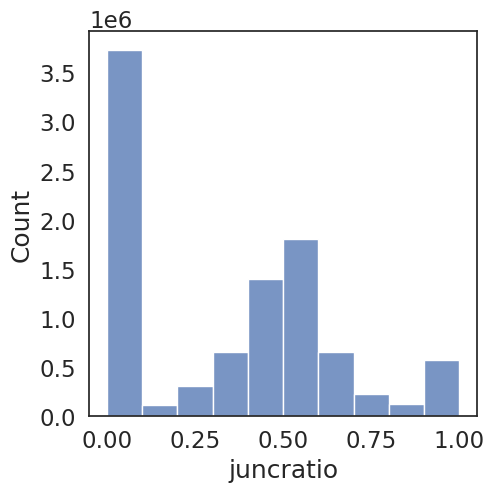

In [10]:
# set figure size to be small
plt.figure(figsize=(5,5))
sns.histplot(final_data.juncratio, bins=10)

### Let's simulate some data!

In [11]:
# update junc_info to only include junctions in clusters_SS
junc_info = junc_info[junc_info["Cluster"].isin(clusters_SS)]
junc_info = junc_info.reset_index(drop=True)
junc_info["new_junction_id_index"] = junc_info.index
junc_info.head()

,junction_id,Cluster,junction_id_index,chr,start,end,new_junction_id_index
0,1_78692220_78694195,114,12,1,78692220,78694195,0
1,1_78694346_78696080,114,13,1,78694346,78696080,1
2,1_74236899_74246079,344,20,1,74236899,74246079,2
3,1_74246114_74248131,344,21,1,74246114,74248131,3
4,1_74255014_74255957,347,22,1,74255014,74255957,4


In [12]:
cell_ids_conversion.cell_type.value_counts()

Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: cell_type, dtype: int64

In [13]:
simulated_counts, cell_types, cell_type_psi, cluster_labels = sim.simulate_junc_counts(cluster_counts_sub, junc_info, cell_types=cell_ids_conversion.cell_type.astype('category'))

Using pre-defined cell types!
The number of cell types is: 4
The number of cells is: 2405
The number of junctions is: 19164


100%|██████████| 6388/6388 [00:18<00:00, 347.89it/s]


The columns to keep are: Index([0, 1, 2, 3], dtype='object')
Done simulating PSI!
Done simulating junc counts!


In [14]:
# save simulated counts, cell types and psi values
sim_juncs_counts = simulated_counts
cell_type_psi_df = cluster_labels

# get variance in simulated psi values across all simulated cell types 
K = len(cell_types)
cell_type_psi_df["difference"] = np.mean(cell_type_psi_df[0:K])
cell_type_psi_df.head()

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


,0,1,2,3,new_junction_id_index,sample_label,Cluster,difference
0,0.155184,0.155184,0.155184,0.155184,0,negative,114,0.252134
2,0.155184,0.155184,0.155184,0.155184,1,negative,114,0.259977
0,0.216247,0.474011,0.314983,0.118132,2,positive,344,0.252134
2,0.216247,0.474011,0.314983,0.118132,3,positive,344,0.259977
0,0.055675,0.106546,0.355142,0.384466,4,positive,347,0.252134


In [15]:
# label anything with absolute difference of 0.2 or less as not cell state associated 
cell_type_psi_df["true_label"] = np.where(abs(cell_type_psi_df["difference"]) >= 0.2, "positive", "negative")
cell_type_psi_df.sort_values(by = ["new_junction_id_index"], inplace = True)
cell_type_psi_df.true_label.value_counts()

positive    19164
Name: true_label, dtype: int64

In [16]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cell_types[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,4.0,0
1,0,1,9.0,0
2,0,2,3.0,0
3,0,3,5.0,0
4,0,4,2.0,0


In [17]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id_x,gene_id_y,new_junction_id_index,new_junc_count,new_cell_type
0,0,12,19.0,24,5.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,4.0,0
1,1713,12,1.0,2,1.0,0.500000,L21-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,0
2,1718,12,3.0,5,2.0,0.600000,L22-B002309-3_57_F-1-1_Mammary_Gland_stromal_cell,Mammary_Gland_stromal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,1.0,3
3,1721,12,12.0,21,9.0,0.571429,L22-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,4.0,0
4,1722,12,36.0,52,16.0,0.692308,L22-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,5.0,0


In [18]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id_x,gene_id_y,junction_id_index,junc_count,new_cell_type
0,0,24,5.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,4.0,0
1,1713,2,1.0,0.500000,L21-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,0
2,1718,5,2.0,0.600000,L22-B002309-3_57_F-1-1_Mammary_Gland_stromal_cell,Mammary_Gland_stromal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,1.0,3
3,1721,21,9.0,0.571429,L22-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,4.0,0
4,1722,52,16.0,0.692308,L22-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,5.0,0


In [19]:
# update cluster_count to be the sum of junction_id_index in each Cluster for each cell
new_clust_counts = sim_data.groupby(["cell_id_index", "Cluster"]).agg({"junc_count": "sum"}).reset_index()
# update column to be cluster_count 
new_clust_counts.rename(columns = {"junc_count": "cluster_count"}, inplace = True)
sim_data.drop(columns = ["cluster_count"], inplace = True)
# merge new_clust_counts with sim_data
sim_data = sim_data.merge(new_clust_counts, on = ["cell_id_index", "Cluster"])

<Axes: xlabel='junc_ratio', ylabel='Count'>

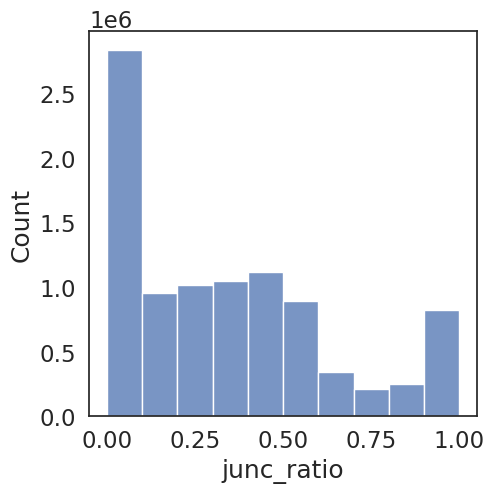

In [20]:
# update juncratio 
sim_data["clustminjunc"] = sim_data["cluster_count"] - sim_data["junc_count"]
sim_data["junc_ratio"] = sim_data["junc_count"] / sim_data["cluster_count"]

# make histogram of junc_ratio
plt.figure(figsize=(5,5))
sns.histplot(sim_data.junc_ratio, bins=10)

### Prep data for model 

In [21]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [22]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
2405
2405


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/Leaflet_load_cluster_data_03.py:45: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [23]:
clust_labels_only = cluster_labels[["Cluster", "sample_label"]].drop_duplicates()
simple_data = sim_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "junc_ratio", "junc_count", "cluster_count"]]
# merge with clust_labels_only 
simple_data = simple_data.merge(clust_labels_only, on = ["Cluster"])
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,junc_ratio,junc_count,cluster_count,sample_label
0,0,114,Mammary_Gland_basal_cell,0,0.129032,4.0,31.0,negative
1,0,114,Mammary_Gland_basal_cell,1,0.290323,9.0,31.0,negative
2,0,114,Mammary_Gland_basal_cell,16117,0.580645,18.0,31.0,negative
3,1713,114,Mammary_Gland_basal_cell,0,0.000000,0.0,2.0,negative
4,1713,114,Mammary_Gland_basal_cell,1,0.000000,0.0,2.0,negative


29641
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland    15
Mammary_Gland_endothelial_cell                            15
Mammary_Gland_stromal_cell                                 9
Mammary_Gland_basal_cell                                   6
Name: cell_type, dtype: int64


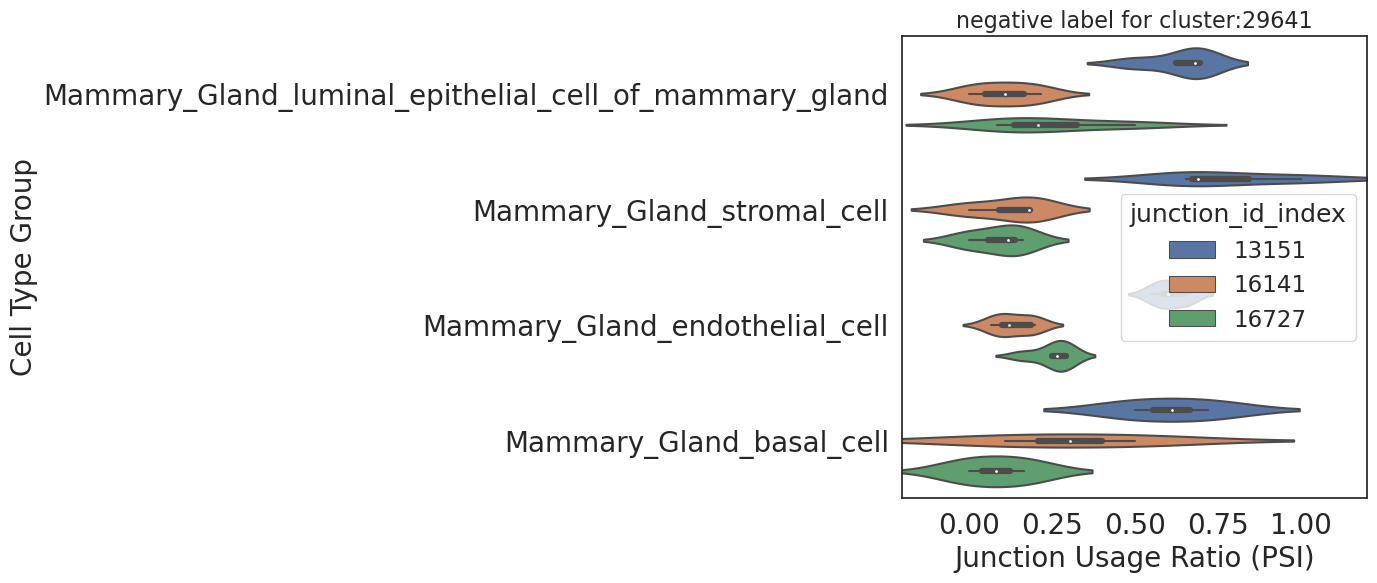

In [24]:
# let's visualize junction usage ratios for a given custer 
# sample clust from simple_data.Cluster.unique()
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
sim.quick_clust_plot(clust, simple_data)

In [25]:
indices = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(sim_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = sim_data['cell_id_index'].max() + 1
num_junctions = sim_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [26]:
indices_counts = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(sim_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = sim_data['cell_id_index'].max() + 1
num_junctions_counts = sim_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [27]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [28]:
# remake junction counts and cluster counts sp.coo_matrix for masking analysis
indices = (sim_data.cell_id_index, sim_data.junction_id_index)
junc_counts = sp.coo_matrix((sim_data.junc_count, indices))
cluster_counts = sp.coo_matrix((sim_data.cluster_count, indices))

### Evaluate model performance when masking some of the input data

In [29]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [30]:
#1. get masked matrix using intron cluster counts for this mouse brain data 

# same masking percentage for all three matrices but generating three different masks
masking_percs = [0.05, 0.1, 0.1001, 0.2]
masks_list = []
seeds_used = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting masked matrix for each masking percentage")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for perc_mask in masking_percs:
    print("The masking percentage is: " + str(perc_mask))
    masked_matrix, seed = generate_mask(cluster_counts, mask_percentage = perc_mask, randomize_seed = True)
    seeds_used.append(seed)
    # append to masks_list
    masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices with masked values 
masked_counts = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting junction and intron cluster count matrices with masked values")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
    # appent masked junction and intron cluster counts to list
    masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting input files for factor model")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = masked_counts[i]
    # get y_tensor and total_counts_tensor via prep_model_input function
    y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
    # append to model_input_files list
    model_input_files.append((y_tensor, total_counts_tensor))

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting masked matrix for each masking percentage
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.05
The seed is:  108027
[5864750 3587235 9314653 6949300 6157834 6022272 7420970 5324456 8330711
 4935658 3168930 1022658 5090611 1565855 8042108  104396 6410282 8150432
   83974 3255620 3751557 8949723 4950242 2015830 9078826 8311598 8647205
 4736523 5620863 1939546 3264503 5763608 9338424 4254189 5169982 3353903
 2943882   19985 6680795 8203864 6836105 1778802 6208965  887864 3722700
 7027404 6126408  596190 6381428 6183048]
Number of entries (junction-cell pairs) masked:  479715.0
The masking percentage is: 0.1
The seed is:  998261
[ 400173 3994912 5776059 5633208 3735325 5815287 8294474 8545061  395418
 5646714 6580463 7849343 5243987 1620847 3321674 5817618 5260796 3314341
 3593617 4890874 3434600 6399093 5314421 4274115 3858762 4811092 9200400
 2749785 4926237 7833

/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:139: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  indices = torch.tensor(np.nonzero(masked_intron_clusts), dtype=torch.long)


The masking percentage is: 0.1
The masking percentage is: 0.1001
The masking percentage is: 0.2


In [31]:
# Now can run factor model on masked data
Ks = [10, 20, 100, 500]
all_Ks_results = {}
# Seeds used for masking 
seeds_used 

# define list of seeds for training factor model 
seeds = [42, 43, 44]

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=True, K=k, seeds=seeds,loss_plot=False, num_epochs=70, lr = 0.01, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

------------------------------------------------
Running factor model for K = 10
------------------------------------------------
The masking percentage is: 0.05
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 42
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 182652714.2711765
Epoch 20, Loss: 157950954.48836783
Epoch 40, Loss: 137520839.32183644
Epoch 60, Loss: 120347753.27303156
Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 43
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 183737457.1121579
Epoch 20, Loss: 158842636.72098753
Epoch 40, Loss: 138100066.4568613
Epoch 60, Loss: 121138303.71545959
Sample from the guide (posterior)
Extract the latent variables
Initialization 3 with seed 44
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 181327953

In [32]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2, rmse = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, rmse, K, perc_mask, J, nepoch])

Calculating performance for K = 10 and masking percentage = 0.05


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:187: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.24123827
Spearman correlation:  0.3485620629479727
L2 error:  0.09172362
RMSE:  0.30285907
L1 error:  0.24150869
Spearman correlation:  0.35231745777950096
L2 error:  0.09173947
RMSE:  0.30288523
L1 error:  0.2399005
Spearman correlation:  0.35176041627458937
L2 error:  0.09116993
RMSE:  0.3019436
Calculating performance for K = 10 and masking percentage = 0.1
L1 error:  0.2413023
Spearman correlation:  0.348177023924525
L2 error:  0.091758355
RMSE:  0.3029164
L1 error:  0.2415696
Spearman correlation:  0.35203714073036163
L2 error:  0.091771744
RMSE:  0.30293852
L1 error:  0.23997574
Spearman correlation:  0.35135887034119356
L2 error:  0.09120885
RMSE:  0.30200803
Calculating performance for K = 10 and masking percentage = 0.1001
L1 error:  0.24130322
Spearman correlation:  0.3482462520630834
L2 error:  0.09175786
RMSE:  0.3029156
L1 error:  0.24157934
Spearman correlation:  0.35199120126109
L2 error:  0.09177906
RMSE:  0.3029506
L1 error:  0.2399766
Spearman correlation

In [33]:
import pandas as pd 
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "K",  "perc_masked" , "J", "num_epochs"])
# save to compressed csv
masked_perf_df.to_csv("masked_perf_df.csv", compression='gzip')

### Summarize masking analysis with plots

In [34]:
masked_perf_df.head()

,seed,l1,r,l2,rmse,K,perc_masked,J,num_epochs
0,42,0.241238,0.348562,0.091724,0.302859,10,0.05,19164,70
1,43,0.241509,0.352317,0.091739,0.302885,10,0.05,19164,70
2,44,0.239900,0.351760,0.091170,0.301944,10,0.05,19164,70
3,42,0.241302,0.348177,0.091758,0.302916,10,0.10,19164,70
4,43,0.241570,0.352037,0.091772,0.302939,10,0.10,19164,70


In [35]:
# make new column combining seed and perc_masked
masked_perf_df['seed_perc_masked'] = masked_perf_df['seed'].astype(str) + "_" + masked_perf_df['perc_masked'].astype(str)
masked_perf_df.head()

# there should be 2 seperate seed_perc_masked values for each K because there were two seperate masks used 
masked_perf_df['seed_perc_masked'].value_counts()

42_0.05      4
43_0.05      4
44_0.05      4
42_0.1       4
43_0.1       4
44_0.1       4
42_0.1001    4
43_0.1001    4
44_0.1001    4
42_0.2       4
43_0.2       4
44_0.2       4
Name: seed_perc_masked, dtype: int64

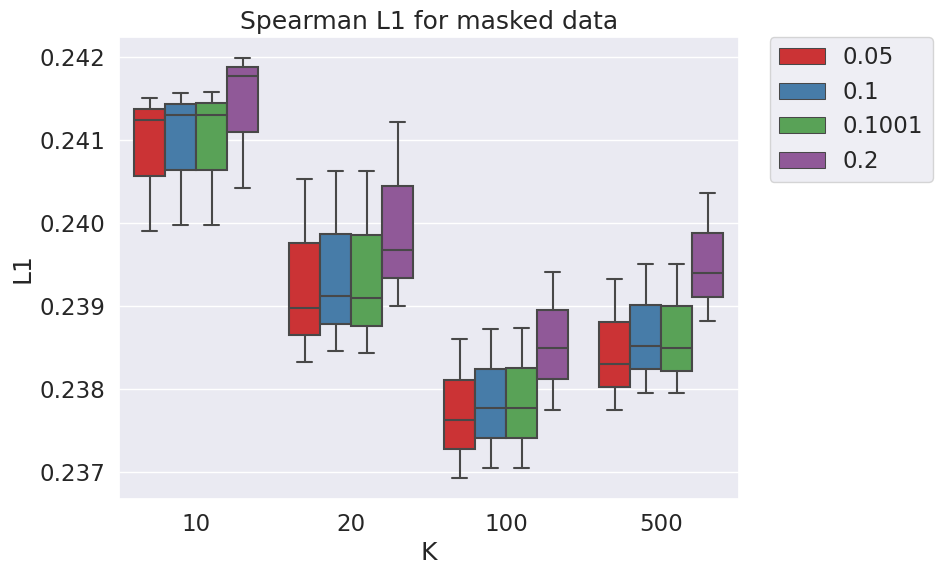

0.23691939


In [36]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
import seaborn as sns
import matplotlib.pyplot as plt 

# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="l1", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("L1")
ax.set_title("Spearman L1 for masked data")

# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

print(masked_perf_df.l1.min())

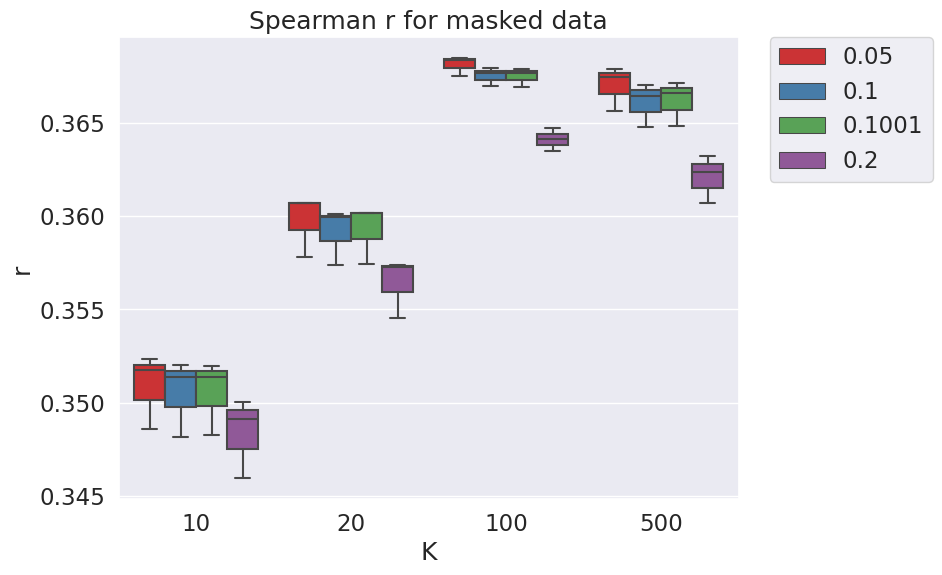

0.36847525853517


In [37]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="r", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.r.max())

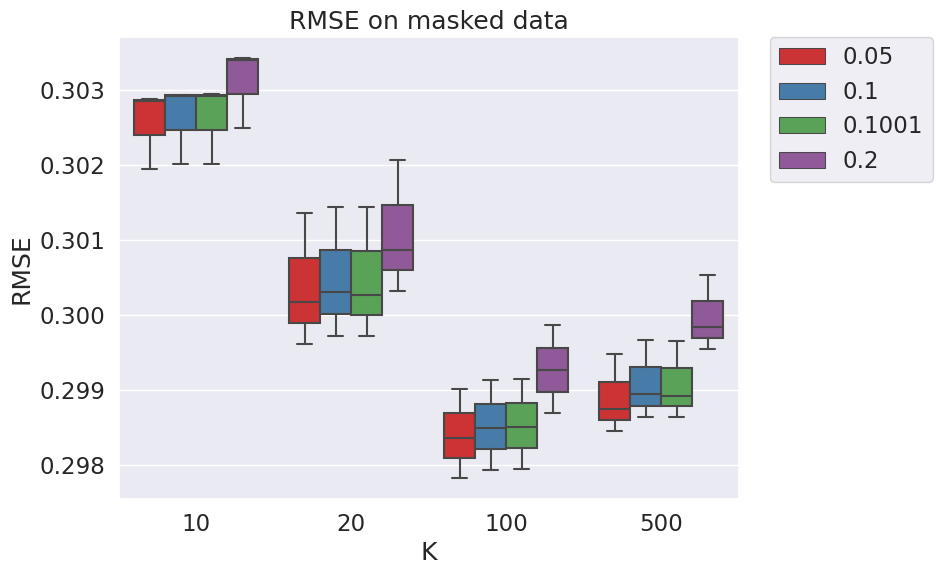

0.2978251


In [38]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="rmse", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("RMSE")
ax.set_title("RMSE on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.rmse.min())

### Run full model

In [39]:
full_total_counts_tensor

tensor(indices=tensor([[    0,     0,     0,  ...,  2005,  2005,  2005],
                       [    0,     1, 16117,  ..., 18765, 18856, 18857]]),
       values=tensor([31., 31., 31.,  ...,  1.,  1.,  1.]),
       size=(2405, 19164), nnz=9594318, layout=torch.sparse_coo)

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 6694
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 192552489.13677368
Epoch 20, Loss: 166748893.5367053
Epoch 40, Loss: 145314663.09855375
Epoch 60, Loss: 127108357.57458994
Epoch 80, Loss: 110986428.60153358
Epoch 100, Loss: 95899272.5043206
Epoch 120, Loss: 81840079.96702337
Epoch 140, Loss: 68806365.88372345
Epoch 160, Loss: 57523981.82405246
Epoch 180, Loss: 48125190.04111149
Epoch 200, Loss: 40545225.20931852
Epoch 220, Loss: 34661478.98394742
Epoch 240, Loss: 30399779.793842252
Epoch 260, Loss: 27200236.902526334
Epoch 280, Loss: 24983378.833842453
Epoch 300, Loss: 23356173.21120998
Epoch 320, Loss: 22151893.393198527
Epoch 340, Loss: 21244325.733957075
Epoch 360, Loss: 20520315.661102317
Epoch 380, Loss: 20002611.0159935
Epoch 400, Loss: 19601939.23858432
Epoch 420, Loss: 19312850.9271

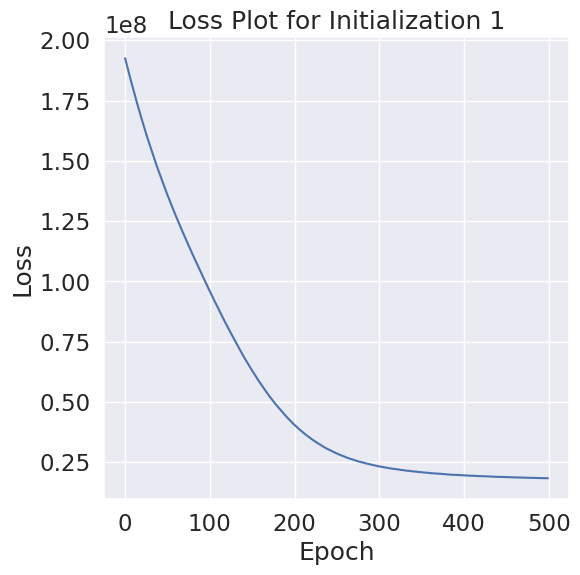

Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 8521
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 190835546.08910263
Epoch 20, Loss: 165129960.3048413
Epoch 40, Loss: 143608808.2107144
Epoch 60, Loss: 125430823.69802535
Epoch 80, Loss: 109476843.56027675
Epoch 100, Loss: 94693309.98639807
Epoch 120, Loss: 80854438.92985074
Epoch 140, Loss: 68177595.75697967
Epoch 160, Loss: 57033234.35479741
Epoch 180, Loss: 47529987.73033524
Epoch 200, Loss: 39942121.803871065
Epoch 220, Loss: 34161511.89320406
Epoch 240, Loss: 29822220.17622934
Epoch 260, Loss: 26744474.623420984
Epoch 280, Loss: 24543763.810689636
Epoch 300, Loss: 22970962.558523975
Epoch 320, Loss: 21851945.94909175
Epoch 340, Loss: 21008278.28874249
Epoch 360, Loss: 20395173.37844136
Epoch 380, Loss: 19919041.474762715
Epoch 400, Loss: 19552174.551480476
Epoch 420, Loss: 19243353.527005322
Epoch 440, Loss: 18996824.89185332
Epoch 460,

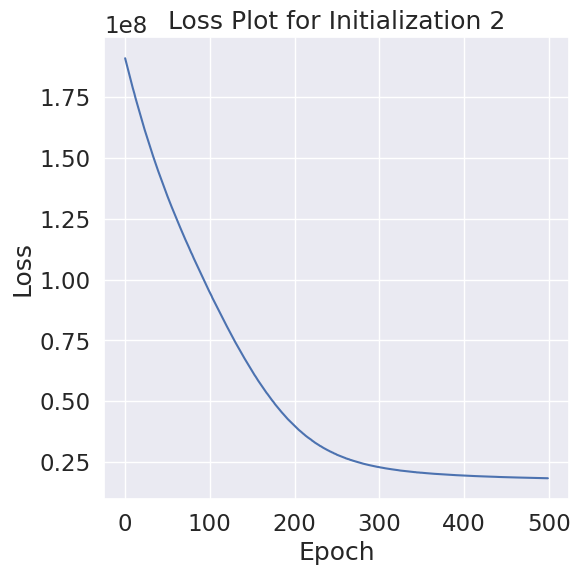

Sample from the guide (posterior)
Extract the latent variables
Initialization 3 with seed 8880
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 195553224.58303264
Epoch 20, Loss: 169356093.10794374
Epoch 40, Loss: 147416474.75438672
Epoch 60, Loss: 128833652.3398346
Epoch 80, Loss: 112231894.15861921
Epoch 100, Loss: 96693804.34452495
Epoch 120, Loss: 82126346.5726893
Epoch 140, Loss: 68778790.71758923
Epoch 160, Loss: 57161955.377290085
Epoch 180, Loss: 47547382.70524846
Epoch 200, Loss: 39983284.93451111
Epoch 220, Loss: 34116523.30428168
Epoch 240, Loss: 29871951.319886997
Epoch 260, Loss: 26759935.82709315
Epoch 280, Loss: 24520622.610619903
Epoch 300, Loss: 22972569.112095345
Epoch 320, Loss: 21794636.238771994
Epoch 340, Loss: 20988941.474036925
Epoch 360, Loss: 20355534.46204333
Epoch 380, Loss: 19883679.894797876
Epoch 400, Loss: 19518807.732360646
Epoch 420, Loss: 19210817.647408832
Epoch 440, Loss: 18957794.465920467
Epoch 4

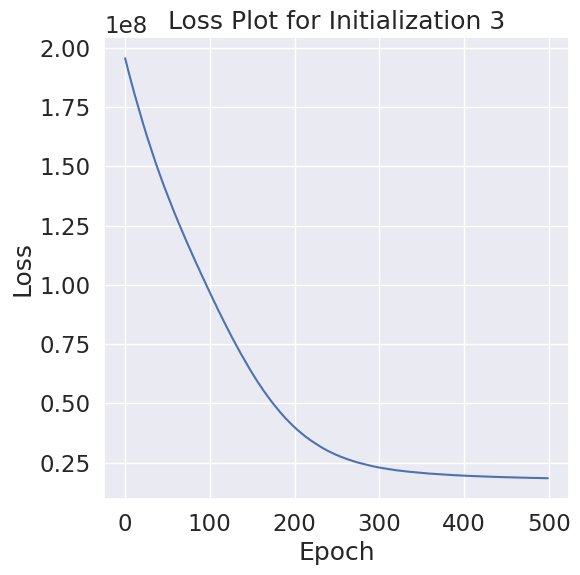

Sample from the guide (posterior)
Extract the latent variables
Initialization 4 with seed 1912
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 199799691.497469
Epoch 20, Loss: 173368419.77510372
Epoch 40, Loss: 151155515.51684314
Epoch 60, Loss: 132258304.64841804
Epoch 80, Loss: 115322206.88414183
Epoch 100, Loss: 99715367.2240991
Epoch 120, Loss: 84853198.8530013
Epoch 140, Loss: 71253914.66435847
Epoch 160, Loss: 59483230.50170361
Epoch 180, Loss: 49611155.978886336
Epoch 200, Loss: 41837431.95059395
Epoch 220, Loss: 35852325.07618162
Epoch 240, Loss: 31374359.11041385
Epoch 260, Loss: 28094980.912747182
Epoch 280, Loss: 25675883.126110442
Epoch 300, Loss: 23916132.59947764
Epoch 320, Loss: 22582419.0534565
Epoch 340, Loss: 21601768.40230272
Epoch 360, Loss: 20840227.185868043
Epoch 380, Loss: 20301560.787398305
Epoch 400, Loss: 19844038.437464137
Epoch 420, Loss: 19483516.761967782
Epoch 440, Loss: 19167197.381319977
Epoch 460, L

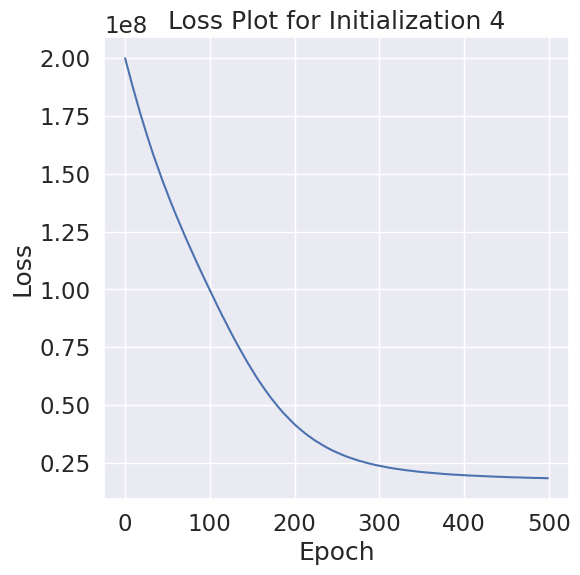

Sample from the guide (posterior)
Extract the latent variables
Initialization 5 with seed 2895
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 191970917.3036176
Epoch 20, Loss: 166126066.42961043
Epoch 40, Loss: 144578327.82378516
Epoch 60, Loss: 126416304.86025144
Epoch 80, Loss: 110382446.93259242
Epoch 100, Loss: 95529001.07884932
Epoch 120, Loss: 81705714.23623064
Epoch 140, Loss: 68956247.55908751
Epoch 160, Loss: 57810851.375509575
Epoch 180, Loss: 48635210.97378313
Epoch 200, Loss: 41126981.59605369
Epoch 220, Loss: 35461652.66258266
Epoch 240, Loss: 31209431.306594532
Epoch 260, Loss: 28104413.102518275
Epoch 280, Loss: 25733603.19266772
Epoch 300, Loss: 24077948.062433515
Epoch 320, Loss: 22793266.77852299
Epoch 340, Loss: 21857310.637595564
Epoch 360, Loss: 21131134.720186263
Epoch 380, Loss: 20543261.842621163
Epoch 400, Loss: 20086364.79617209
Epoch 420, Loss: 19710523.2655407
Epoch 440, Loss: 19390653.343029764
Epoch 460

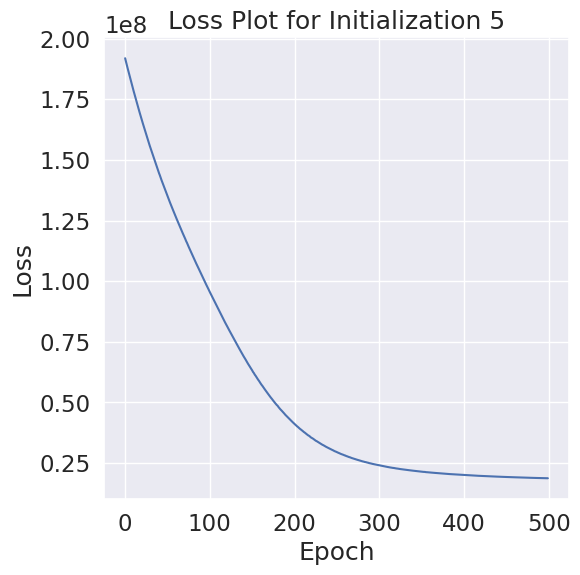

Sample from the guide (posterior)
Extract the latent variables
Initialization 6 with seed 6219
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 190900995.46715695
Epoch 20, Loss: 165163414.31452248
Epoch 40, Loss: 143602105.98035398
Epoch 60, Loss: 125417438.67872852
Epoch 80, Loss: 109327060.81314707
Epoch 100, Loss: 94464254.20911437
Epoch 120, Loss: 80666067.71280819
Epoch 140, Loss: 68071705.52126703
Epoch 160, Loss: 56853181.76556884
Epoch 180, Loss: 47462015.68023763
Epoch 200, Loss: 39948283.71691256
Epoch 220, Loss: 34157778.31464295
Epoch 240, Loss: 29903159.07203176
Epoch 260, Loss: 26820717.523880295
Epoch 280, Loss: 24535300.366620794
Epoch 300, Loss: 22987718.99225953
Epoch 320, Loss: 21851067.91578746
Epoch 340, Loss: 20994919.340880867
Epoch 360, Loss: 20369033.27524243
Epoch 380, Loss: 19901652.4959059
Epoch 400, Loss: 19522196.80516242
Epoch 420, Loss: 19209473.16369804
Epoch 440, Loss: 18950491.20350547
Epoch 460, Lo

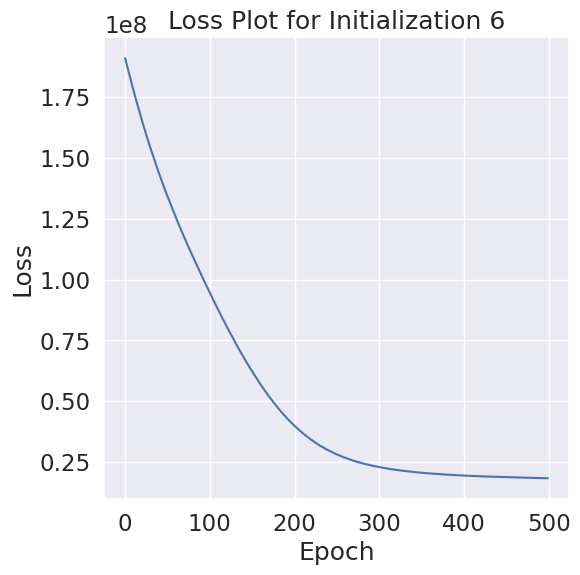

Sample from the guide (posterior)
Extract the latent variables
Initialization 7 with seed 3690
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 193887659.73772883
Epoch 20, Loss: 167814560.0848339
Epoch 40, Loss: 145952036.5656638
Epoch 60, Loss: 127650055.68493703
Epoch 80, Loss: 111395174.13740395
Epoch 100, Loss: 96290564.72481728
Epoch 120, Loss: 82021136.44832134
Epoch 140, Loss: 68964118.09050143
Epoch 160, Loss: 57503944.64786865
Epoch 180, Loss: 47954105.19888081
Epoch 200, Loss: 40498608.08428924
Epoch 220, Loss: 34653173.640221275
Epoch 240, Loss: 30258096.340702243
Epoch 260, Loss: 26987004.8972439
Epoch 280, Loss: 24682273.58970631
Epoch 300, Loss: 22985302.151517354
Epoch 320, Loss: 21776980.267922044
Epoch 340, Loss: 20885555.104500208
Epoch 360, Loss: 20227235.595478073
Epoch 380, Loss: 19738666.73425583
Epoch 400, Loss: 19336567.36003822
Epoch 420, Loss: 19026970.888630286
Epoch 440, Loss: 18762648.78058722
Epoch 460, 

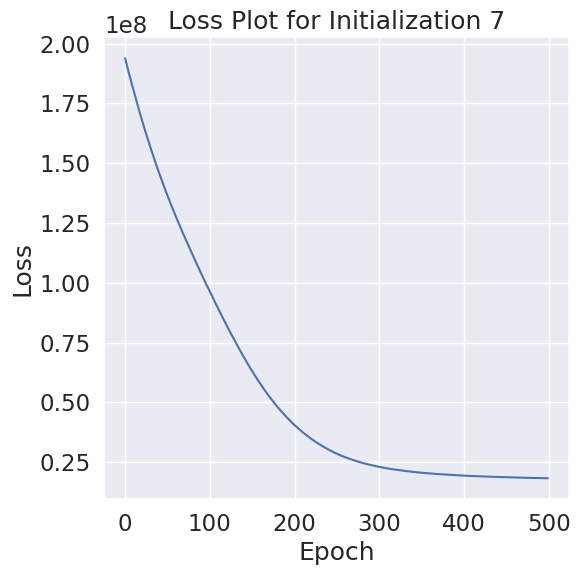

Sample from the guide (posterior)
Extract the latent variables
Initialization 8 with seed 4745
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 193376515.7879747
Epoch 20, Loss: 167393955.60667163
Epoch 40, Loss: 145714728.53314522
Epoch 60, Loss: 127454140.00194256
Epoch 80, Loss: 111116593.52738532
Epoch 100, Loss: 95989109.99354106
Epoch 120, Loss: 81773997.77526575
Epoch 140, Loss: 68765630.59093042
Epoch 160, Loss: 57356992.01500853
Epoch 180, Loss: 47804482.13410883
Epoch 200, Loss: 40256820.281025514
Epoch 220, Loss: 34575285.73736249
Epoch 240, Loss: 30387401.373795323
Epoch 260, Loss: 27315005.109017093
Epoch 280, Loss: 25071284.571906112
Epoch 300, Loss: 23430138.540293362
Epoch 320, Loss: 22181706.963100247
Epoch 340, Loss: 21252081.701786123
Epoch 360, Loss: 20548525.714395497
Epoch 380, Loss: 19986832.055917844
Epoch 400, Loss: 19572578.97537961
Epoch 420, Loss: 19240094.54761167
Epoch 440, Loss: 18965290.812089898
Epoch 

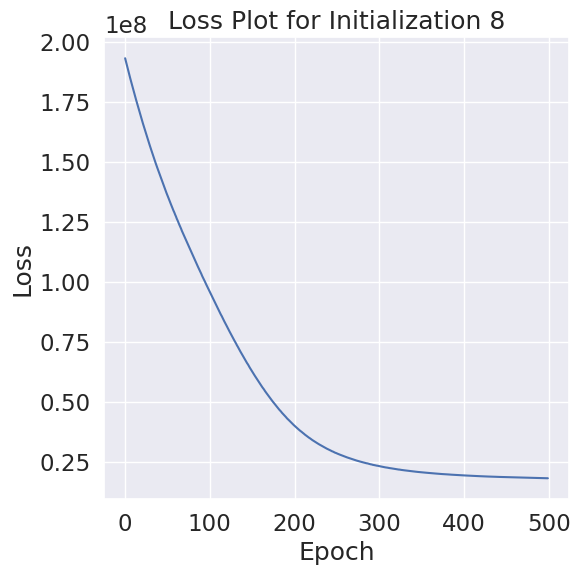

Sample from the guide (posterior)
Extract the latent variables
Initialization 9 with seed 477
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 194944185.3697789
Epoch 20, Loss: 168802398.05388483
Epoch 40, Loss: 147001662.62855214
Epoch 60, Loss: 128468952.71177647
Epoch 80, Loss: 112042568.07009616
Epoch 100, Loss: 96768443.16877119
Epoch 120, Loss: 82341805.42607577
Epoch 140, Loss: 69102878.66428676
Epoch 160, Loss: 57757260.42088418
Epoch 180, Loss: 48217609.0410743
Epoch 200, Loss: 40686008.94732684
Epoch 220, Loss: 34881032.807714805
Epoch 240, Loss: 30475213.701753378
Epoch 260, Loss: 27204602.785624787
Epoch 280, Loss: 24856891.919250477
Epoch 300, Loss: 23179937.14116615
Epoch 320, Loss: 21899694.668805353
Epoch 340, Loss: 20985326.740751483
Epoch 360, Loss: 20304566.960868977
Epoch 380, Loss: 19788264.830096155
Epoch 400, Loss: 19379368.30683618
Epoch 420, Loss: 19066004.8599414
Epoch 440, Loss: 18805551.35618577
Epoch 460, 

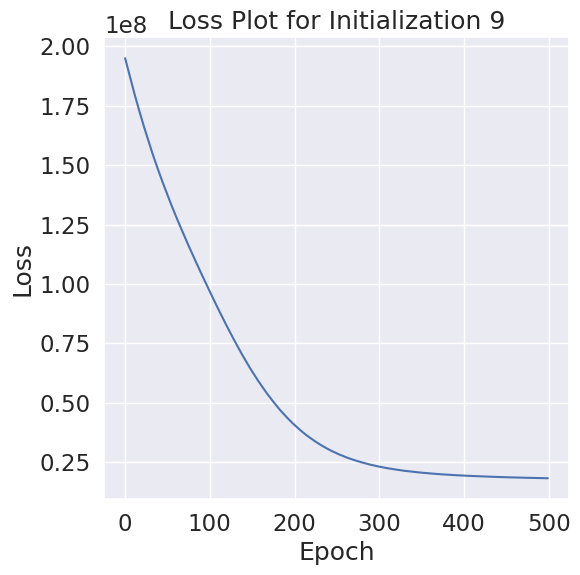

Sample from the guide (posterior)
Extract the latent variables
Initialization 10 with seed 3682
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 195516243.94824025
Epoch 20, Loss: 169151825.83461797
Epoch 40, Loss: 147173948.03810492
Epoch 60, Loss: 128487409.30488828
Epoch 80, Loss: 111970950.47211683
Epoch 100, Loss: 96532147.97738215
Epoch 120, Loss: 82112360.09193559
Epoch 140, Loss: 69019138.43684173
Epoch 160, Loss: 57660354.766532674
Epoch 180, Loss: 48256279.19418806
Epoch 200, Loss: 40591141.43604092
Epoch 220, Loss: 34821529.36157291
Epoch 240, Loss: 30500066.348218054
Epoch 260, Loss: 27408705.893722285
Epoch 280, Loss: 25058300.41259775
Epoch 300, Loss: 23416914.26692433
Epoch 320, Loss: 22253835.77564881
Epoch 340, Loss: 21369456.41033052
Epoch 360, Loss: 20725187.19054167
Epoch 380, Loss: 20172340.56942951
Epoch 400, Loss: 19782751.924902763
Epoch 420, Loss: 19418100.41916296
Epoch 440, Loss: 19165593.71117662
Epoch 460,

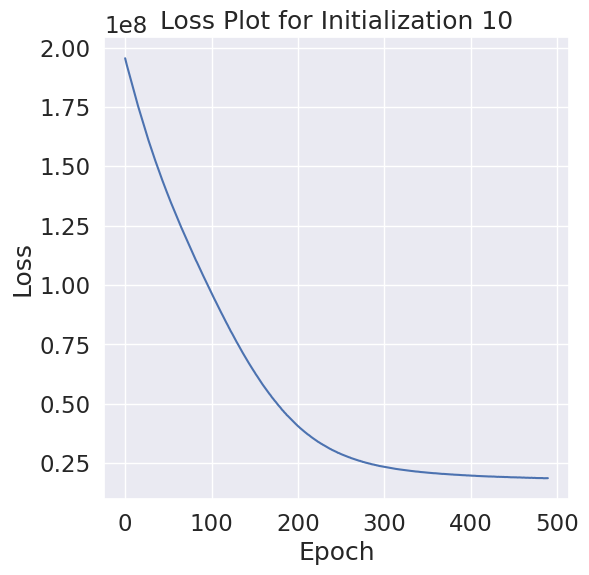

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [40]:
reload(factor_model)
best_K = 100 
K = best_K

all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=10, use_global_prior=True, K=K, lr=0.01, loss_plot=True, num_epochs=500, save_to_file = False)

In [41]:
# extract latent variables for all iterations 
latent_results = {} 
for i in range(len(all_results)):
    latent_vars = all_results[i]['latent_vars']
    pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
    conc = latent_vars["conc"] # one scaling value 
    assign_post = latent_vars["assign"]
    psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster
    a = latent_vars["a"] 
    b = latent_vars["b"] 
    print("The inferred concentration parameter is: " + str(conc))
    print("The inferred pi parameter is: " + str(pi))
    # add all latent variables to latent_results dictionary
    latent_results[i] = {"pi": pi, "conc": conc, "assign_post": assign_post, "psis": psis, "a": a, "b": b}

The inferred concentration parameter is: 14.504901
The inferred pi parameter is: [0.01413374 0.01303047 0.01285806 0.0139025  0.02245145 0.01253192
 0.06136627 0.03376384 0.01429434 0.04527318 0.01026759 0.00922047
 0.00983561 0.0293477  0.00965572 0.00934862 0.00981201 0.00911985
 0.01721708 0.00909846 0.00910249 0.009224   0.01375313 0.01244368
 0.00853797 0.01789392 0.01327393 0.00833724 0.0081729  0.02533047
 0.0074137  0.01252401 0.00780191 0.00762256 0.0129658  0.00755327
 0.01450218 0.00836459 0.00766498 0.00716042 0.00710108 0.00821382
 0.00851112 0.00995051 0.00983788 0.00989762 0.01181843 0.0075049
 0.00788117 0.00814267 0.00914147 0.00682588 0.00865568 0.00772355
 0.00756308 0.00638386 0.00654018 0.0088448  0.00962196 0.0070169
 0.00767038 0.00736191 0.00887734 0.0081377  0.00826344 0.00643155
 0.00570652 0.00748408 0.00575394 0.00850658 0.00621822 0.00757912
 0.00584274 0.00629906 0.00615496 0.0061898  0.00699869 0.00776112
 0.0058963  0.00535759 0.00609456 0.00654655 0.006

In [42]:
cell_types_id = sim_data[["cell_id", "cell_id_index", "new_cell_type"]].drop_duplicates()
# reorder by cell_id_index
cell_types_id = cell_types_id.sort_values(by = ["cell_id_index"])
cell_types_id.head()

,cell_id,cell_id_index,new_cell_type
0,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,0,0
6429,A10-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,1,0
1677,A10-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,2,0
1473,A10-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,3,0
6420,A10-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,4,0


In [43]:
cell_types_id.new_cell_type.value_counts()

0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64

In [44]:
# from dictionary of latent variables, get the assign_post for each iteration and add to a dataframe
assign_post = []
for i in range(len(latent_results)):
    assign_post_df = pd.DataFrame(latent_results[i]["assign_post"])
    assign_post_df["new_cell_type"] = cell_types_id.new_cell_type.values
    print(assign_post_df.new_cell_type.value_counts())
    assign_post.append(latent_results[i]["assign_post"])

0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64


### Evaluate latent factor space

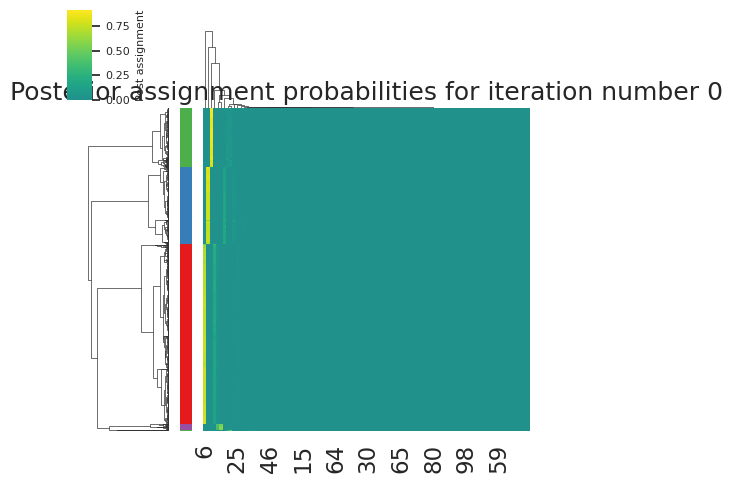

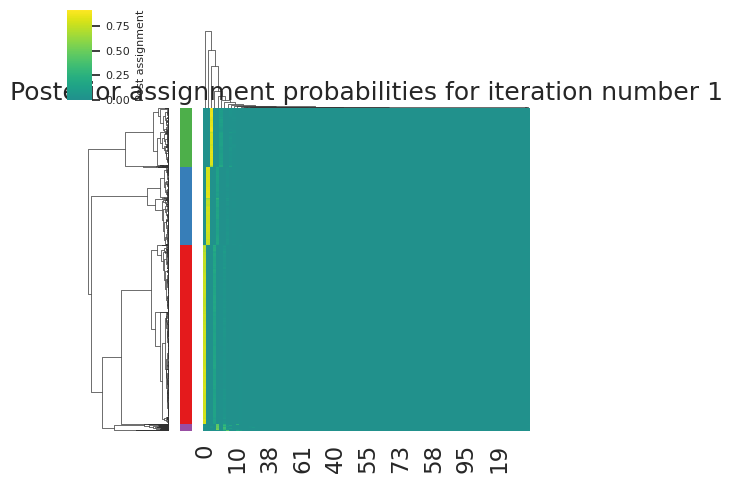

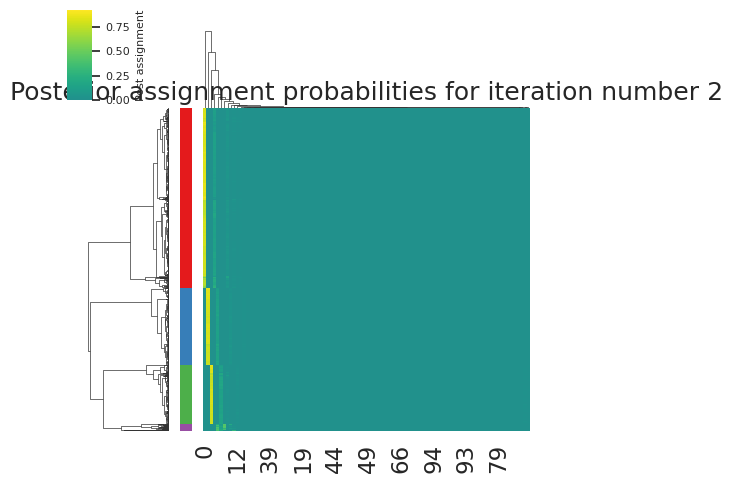

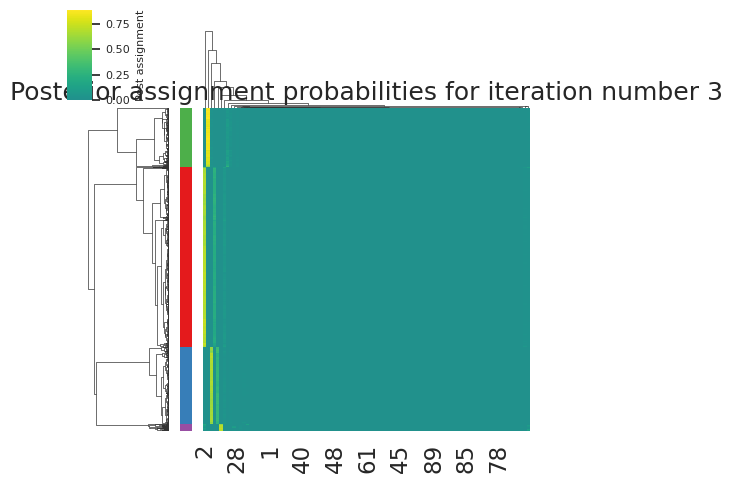

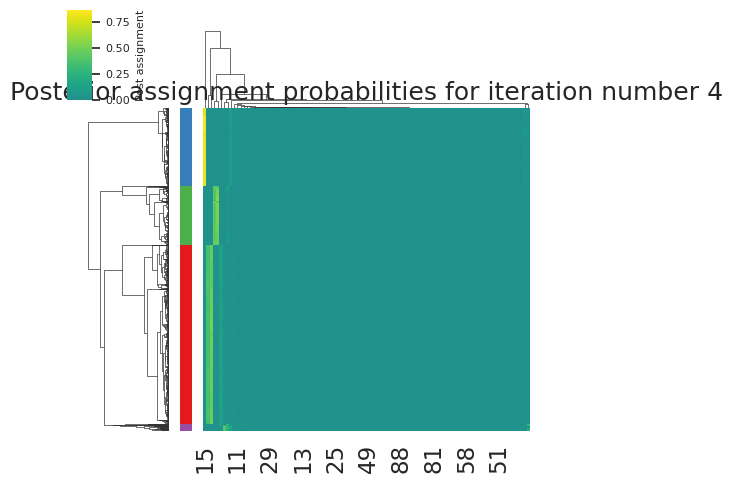

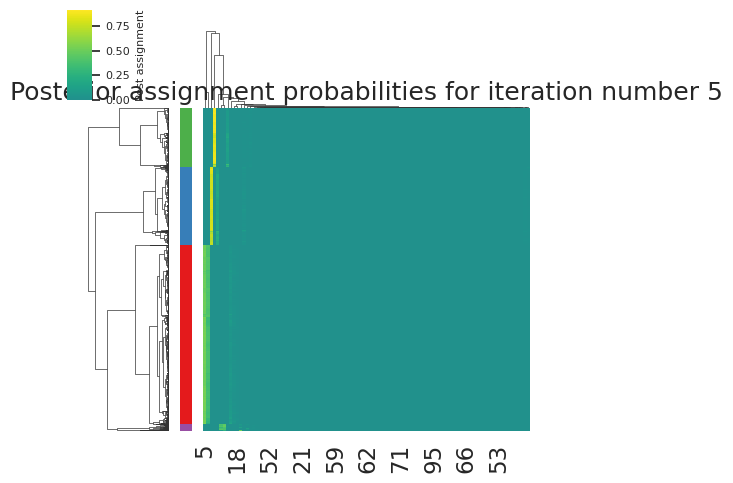

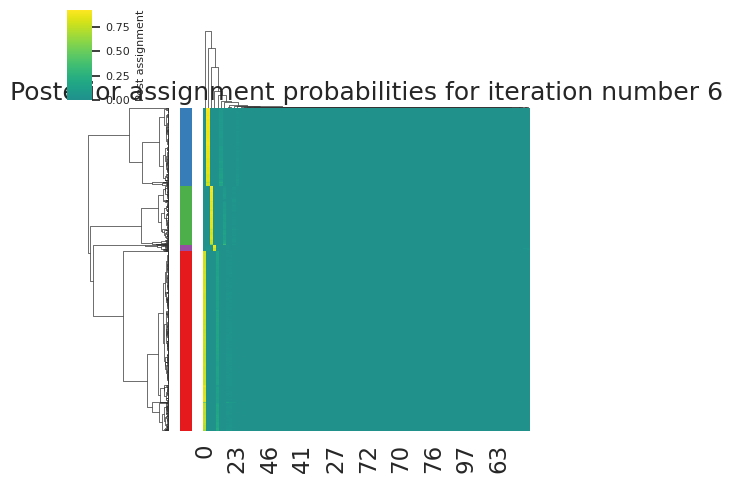

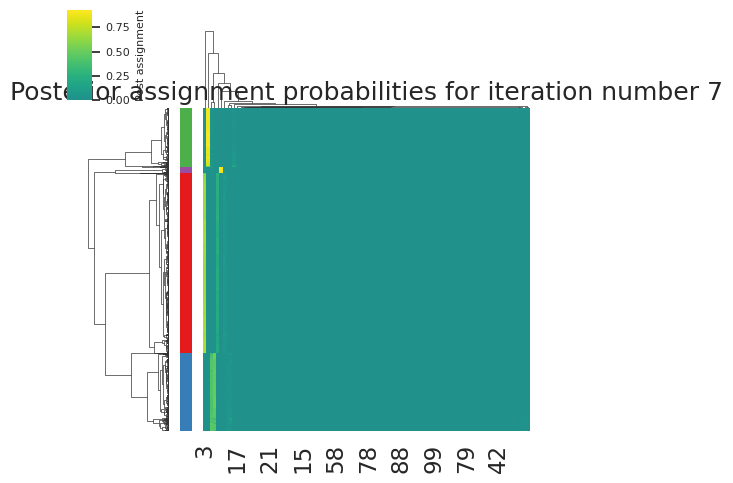

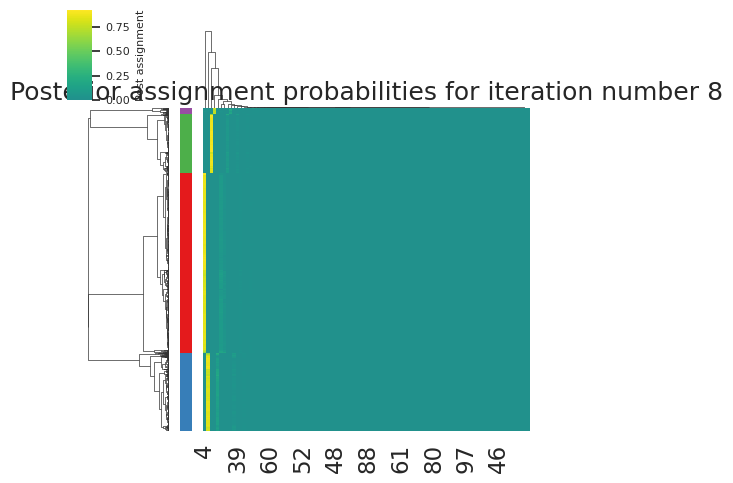

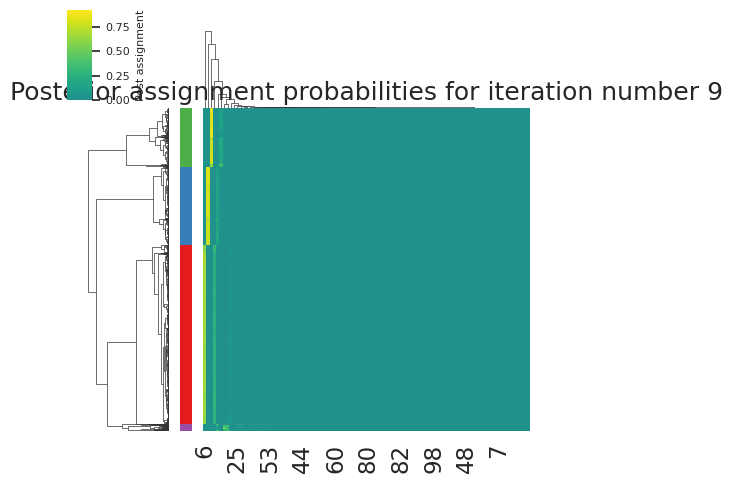

In [45]:
import seaborn as sns

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_id['new_cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_id['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_id.new_cell_type.values

# create colours for each cell type 
cell_type_colors = {new_cell_type: color for new_cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[new_cell_type] for new_cell_type in cell_types]

for i in range(len(assign_post)):
    cluster = sns.clustermap(
        data=assign_post[i],
        method='complete',
        cmap="viridis",
        annot=False,
        fmt=".2f",
        yticklabels=False,
        figsize=(5, 5),
        center=0,
        row_colors=row_colors,  # Apply row colors
        cbar_kws={'label': 'Post assignment'} 
        )
    cluster.cax.set_ylabel('Post assignment', size=8)
    # add title 
    cluster.ax_heatmap.set_title('Posterior assignment probabilities for iteration number ' + str(i))
    # Increase font size for color bar tick labels:
    cbar_ax = cluster.cax
    for label in cbar_ax.yaxis.get_ticklabels():
        label.set_size(8)

In [46]:
umaps = []

for i in range(len(assign_post)):
    print("Running UMAP for iteration number " + str(i))
    # make UMAP using average assign_post across seeds and color points by cell_type 
    reducer = umap.UMAP(n_components=10, random_state=42)
    embedding = reducer.fit_transform(assign_post[i])
    umaps.append(embedding)

Running UMAP for iteration number 0
Running UMAP for iteration number 1
Running UMAP for iteration number 2
Running UMAP for iteration number 3
Running UMAP for iteration number 4
Running UMAP for iteration number 5
Running UMAP for iteration number 6
Running UMAP for iteration number 7
Running UMAP for iteration number 8
Running UMAP for iteration number 9


In [47]:
# make function for plotting UMAPs 
def umap_plot(umap, cell_type_colors, cell_types):
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(4, 4))    
    plt.scatter(umap[:, 0], umap[:, 1],
        c=[cell_type_colors[cell_type] for cell_type in cell_types],
        s=8, alpha=0.4)
    # xlab 
    plt.xlabel("UMAP 1")
    # ylab
    plt.ylabel("UMAP 2")

Plotting UMAP for iteration number 0
Plotting UMAP for iteration number 1
Plotting UMAP for iteration number 2
Plotting UMAP for iteration number 3
Plotting UMAP for iteration number 4
Plotting UMAP for iteration number 5
Plotting UMAP for iteration number 6
Plotting UMAP for iteration number 7
Plotting UMAP for iteration number 8
Plotting UMAP for iteration number 9


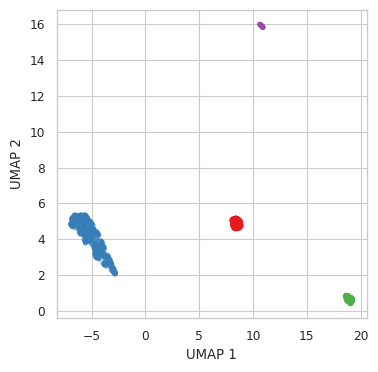

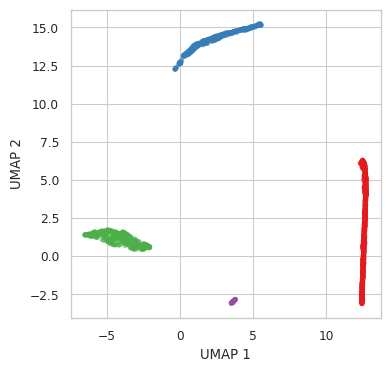

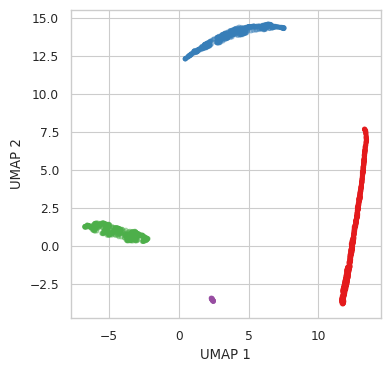

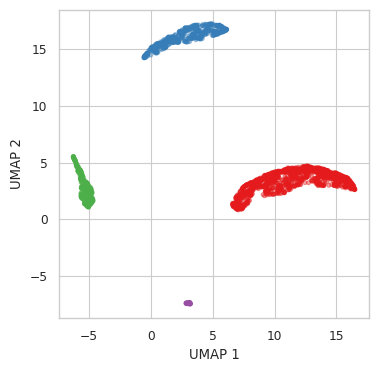

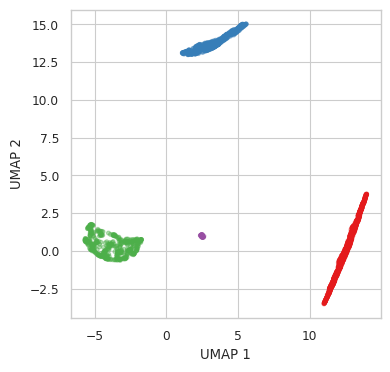

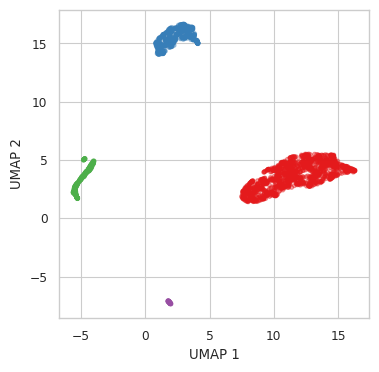

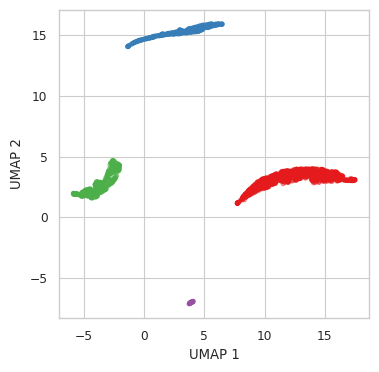

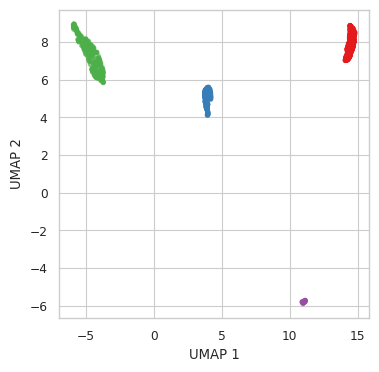

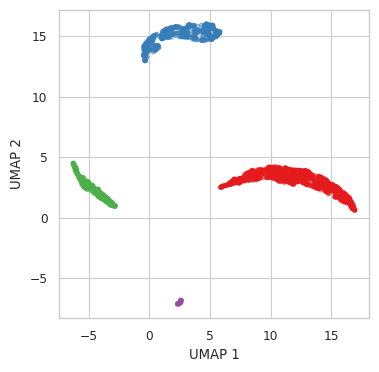

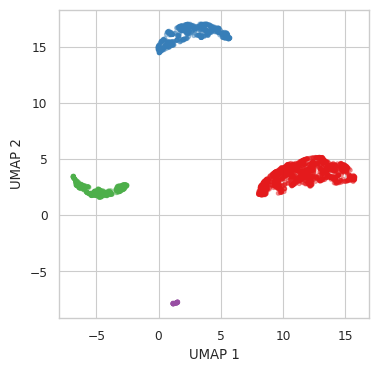

In [48]:
for i in range(len(umaps)):
    print("Plotting UMAP for iteration number " + str(i))
    umap_plot(umaps[i], cell_type_colors, cell_types)

Text(0, 0.5, 'Number of cells')

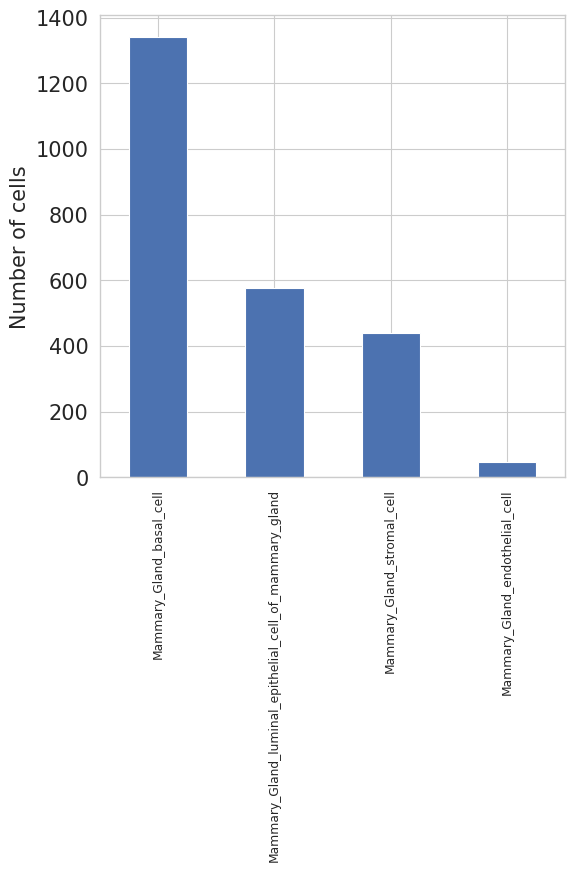

In [49]:
# make a histogram of number of cells in each cell type in cell_ids_conversion
cell_ids_conversion.cell_type.value_counts().plot(kind='bar') 

# increase font of y-axis labels and ticks 
plt.yticks(fontsize=15)
plt.ylabel("Number of cells", fontsize=15)

6      Factor6
9      Factor9
7      Factor7
13    Factor13
29    Factor29
Name: factor, dtype: object


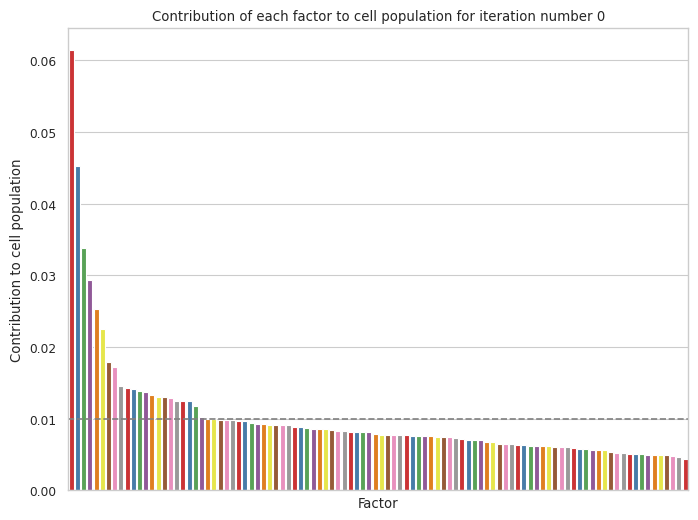

0      Factor0
6      Factor6
13    Factor13
11    Factor11
18    Factor18
Name: factor, dtype: object


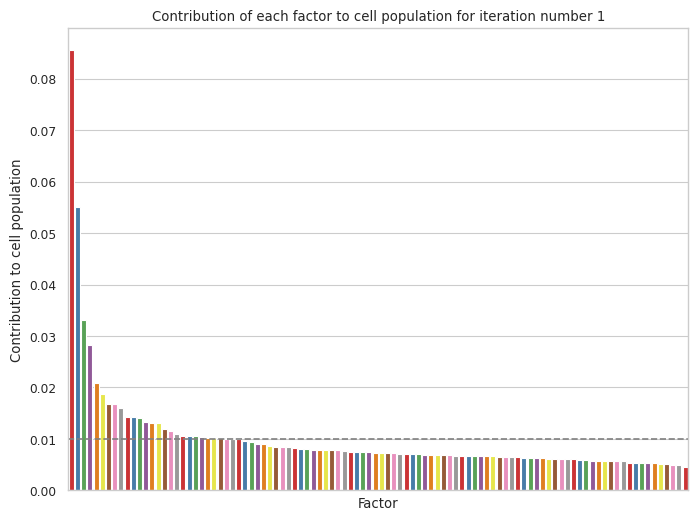

0      Factor0
2      Factor2
6      Factor6
12    Factor12
7      Factor7
Name: factor, dtype: object


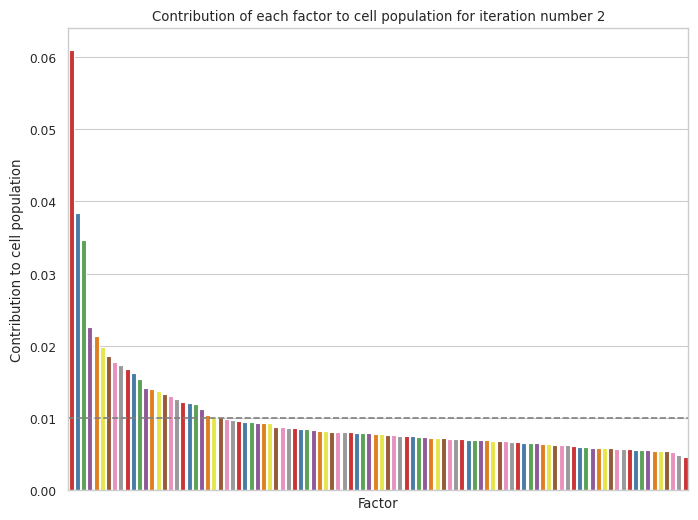

2      Factor2
9      Factor9
7      Factor7
0      Factor0
12    Factor12
Name: factor, dtype: object


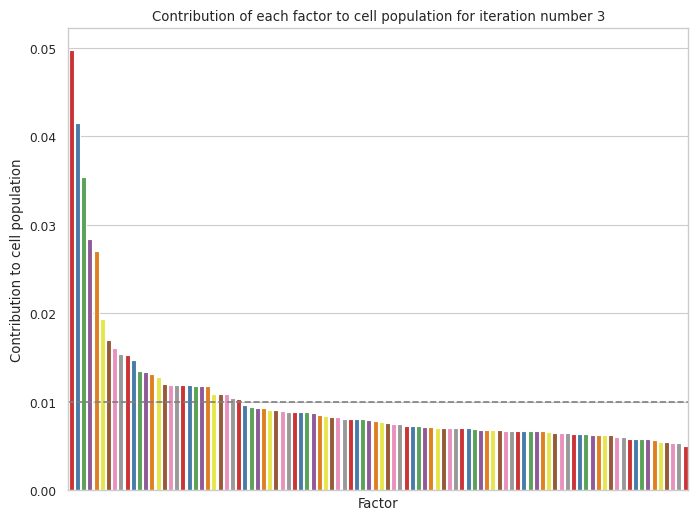

1    Factor1
2    Factor2
4    Factor4
5    Factor5
7    Factor7
Name: factor, dtype: object


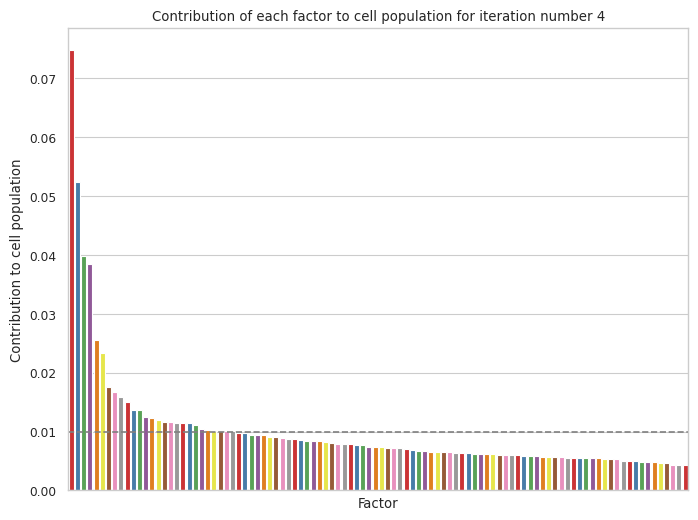

5      Factor5
10    Factor10
11    Factor11
13    Factor13
19    Factor19
Name: factor, dtype: object


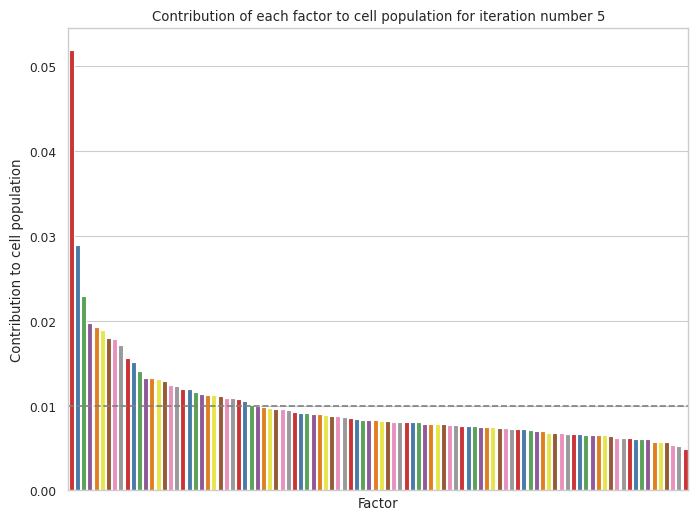

0      Factor0
1      Factor1
4      Factor4
18    Factor18
15    Factor15
Name: factor, dtype: object


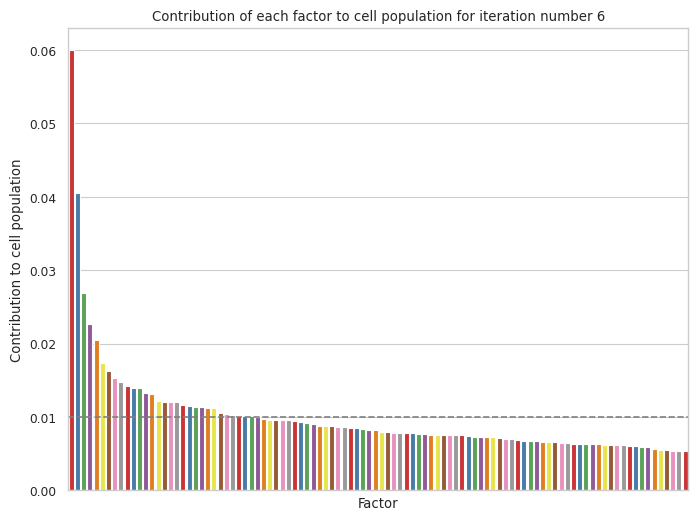

3      Factor3
7      Factor7
10    Factor10
1      Factor1
9      Factor9
Name: factor, dtype: object


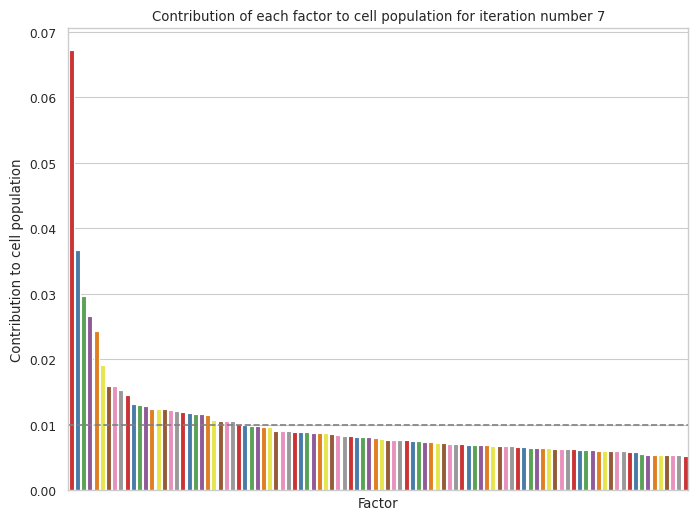

4      Factor4
10    Factor10
0      Factor0
11    Factor11
20    Factor20
Name: factor, dtype: object


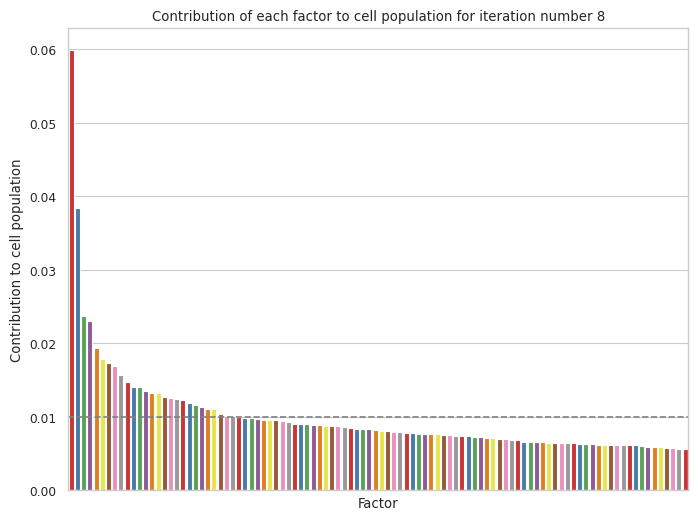

6      Factor6
12    Factor12
9      Factor9
15    Factor15
5      Factor5
Name: factor, dtype: object


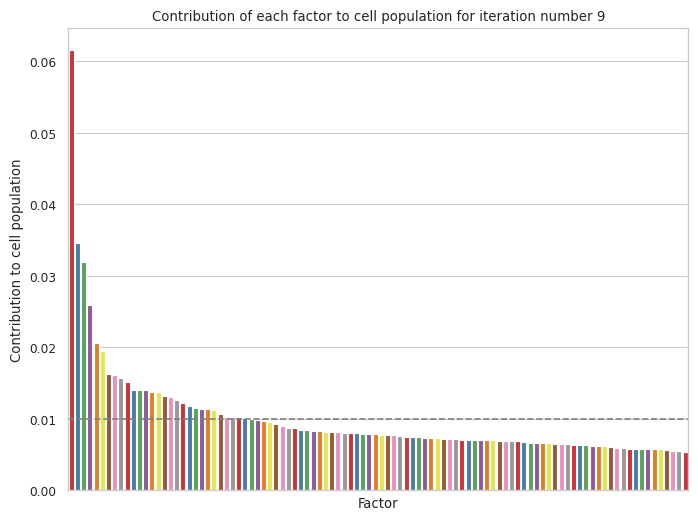

In [50]:
# loop through all restults and make barplot of contribute of each factor to cell population pi

for i in range(len(latent_results)):
    pi = latent_results[i]["pi"]
    pi_df = pd.DataFrame(pi, columns = ["pi"])
    pi_df["factor"] = "Factor" + pi_df.index.astype(str)
    pi_df["iteration"] = i
    pi_df["iteration"] = pi_df["iteration"].astype(str)
    pi_df["factor"] = pi_df["factor"].astype(str)
    pi_df["pi"] = pi_df["pi"].astype(float)
    # order by pi
    pi_df = pi_df.sort_values(by = ["pi"], ascending = False)
    # prnt the top 5 factors 
    print(pi_df.factor.head())
    # make barplot
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x="factor", y="pi", data=pi_df, palette="Set1")
    # draw a line at 0.01 
    ax.axhline(0.01, color='grey', linestyle='--')
    ax.set_xlabel("Factor")
    # remove xaxis ticks 
    ax.set_xticks([])
    ax.set_ylabel("Contribution to cell population")
    ax.set_title("Contribution of each factor to cell population for iteration number " + str(i))
    plt.show()

In [51]:
# let's see which junctions contribute the most to each factor
latent_results[0]["psis"].shape

(100, 19164)

In [52]:
# average junction behaviour of 0.4 means that given 100 reads, this junction will likely get 40 reads

can make simulation more hierarchical first sample psi_o ~ beta(0.5, 0.5) and psi_c for each cell type 

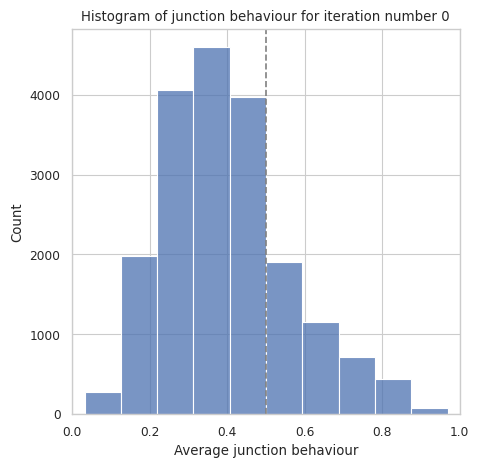

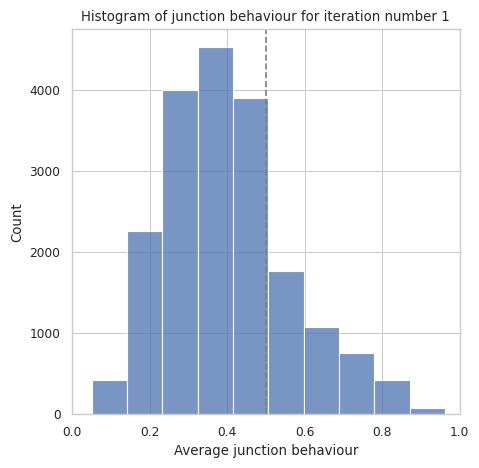

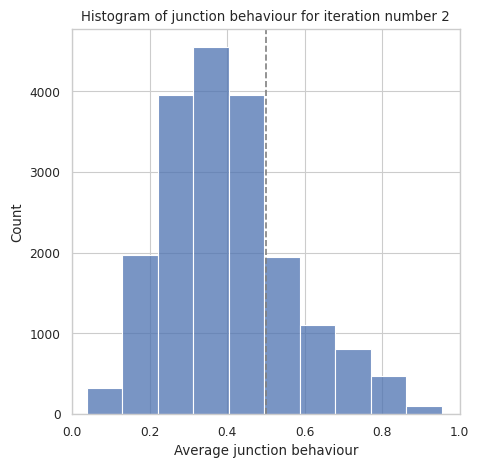

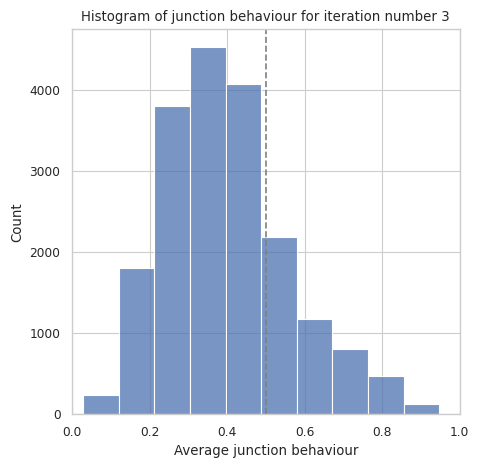

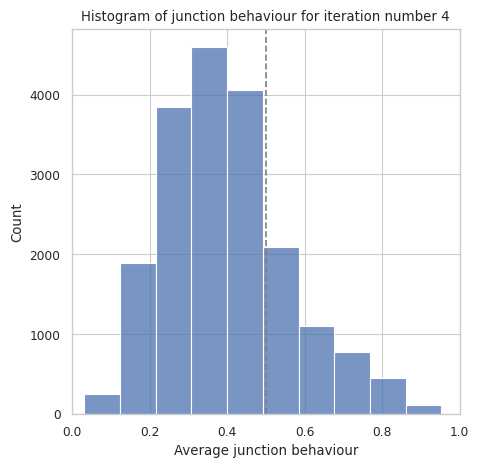

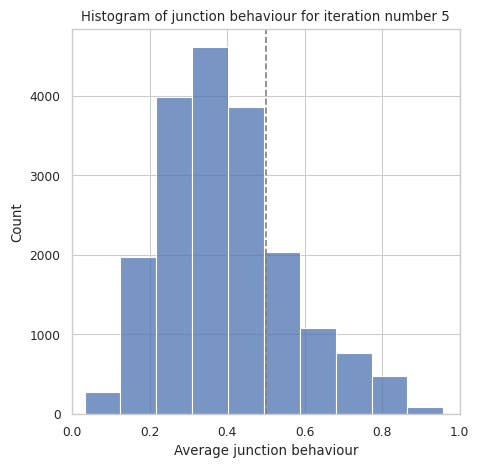

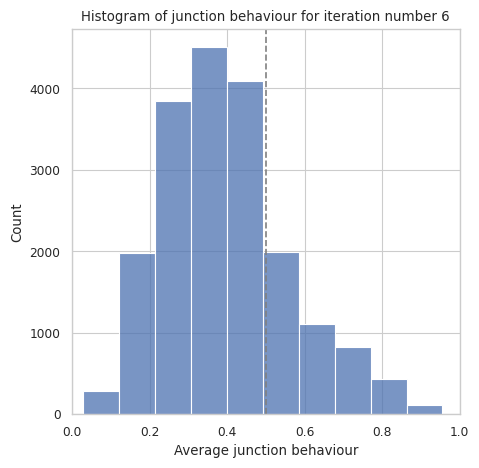

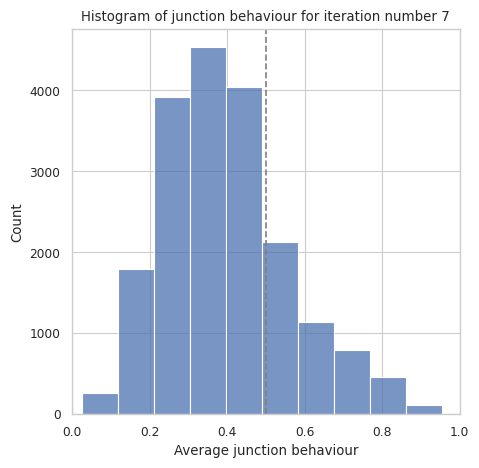

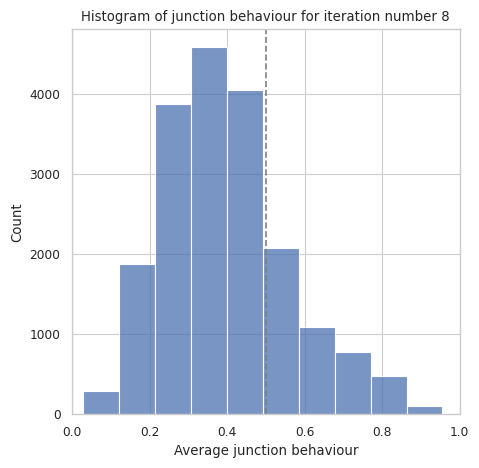

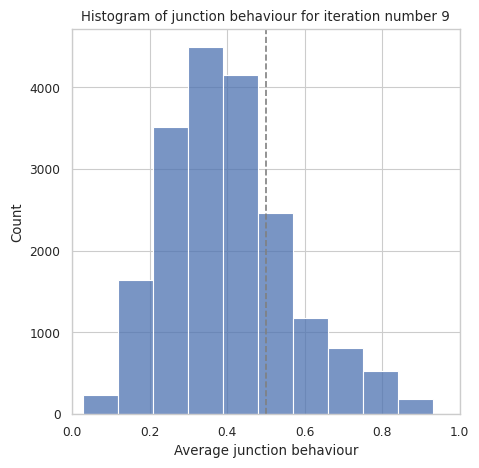

In [53]:
# get average junction behaviour 
for i in range(len(latent_results)):
    junc_beh = latent_results[i]["a"] / (latent_results[i]["a"] + latent_results[i]["b"])
    junc_beh_df = pd.DataFrame(junc_beh, columns = ["junction_beh"])
    junc_beh_df["junction_id_index"] = junc_beh_df.index
    junc_beh_df["iteration"] = i
    # make a histogram of junction behaviour
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(5, 5))
    sns.histplot(junc_beh_df.junction_beh, bins=10)
    # make xaxis 0 to 1 
    plt.xlim(0, 1)
    plt.xlabel("Average junction behaviour")
    # draw a line a 0.5 
    plt.axvline(0.5, color='grey', linestyle='--')
    plt.title("Histogram of junction behaviour for iteration number " + str(i))
    plt.show()

In [54]:
# now let's look at psis 
psis = latent_results[0]["psis"]
psis.shape # K by J 

# rotate so it's J by K
psis = psis.T

# now convert to dataframe
psis_df = pd.DataFrame(psis)
psis_df["junction_id_index"] = psis_df.index

# calculate junction standard deviation across the K factors 
psis_df["std"] = psis_df[psis_df.columns[0:K]].std(axis=1)

# sort by std
psis_df = psis_df.sort_values(by = ["std"], ascending = False)
psis_df.head()

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,junction_id_index,std
17270,0.182099,0.234886,0.652152,0.171926,0.006492,0.922172,0.993416,0.006797,0.008067,0.996736,...,0.134605,0.764989,0.205716,0.156684,0.167123,0.914691,0.397656,0.882622,17270,0.355799
10143,0.919311,0.764942,0.552483,0.932839,0.964161,0.995940,0.138808,0.994237,0.966559,0.433976,...,0.936579,0.409189,0.805009,0.970449,0.957686,0.313969,0.572810,0.358824,10143,0.352963
16083,0.088731,0.081309,0.470188,0.069181,0.028621,0.224827,0.991550,0.019528,0.011801,0.992188,...,0.223224,0.834552,0.170365,0.201384,0.202444,0.705566,0.301207,0.791202,16083,0.352395
14348,0.129972,0.545856,0.044717,0.049883,0.004741,0.252959,0.742544,0.003724,0.944954,0.109599,...,0.110702,0.330911,0.100291,0.258079,0.244336,0.752485,0.370375,0.480643,14348,0.351847
12413,0.153878,0.811737,0.215967,0.099384,0.034203,0.955517,0.956430,0.019793,0.007436,0.971673,...,0.128342,0.458680,0.053491,0.221574,0.168447,0.653273,0.059647,0.696179,12413,0.349910


<Figure size 800x600 with 0 Axes>

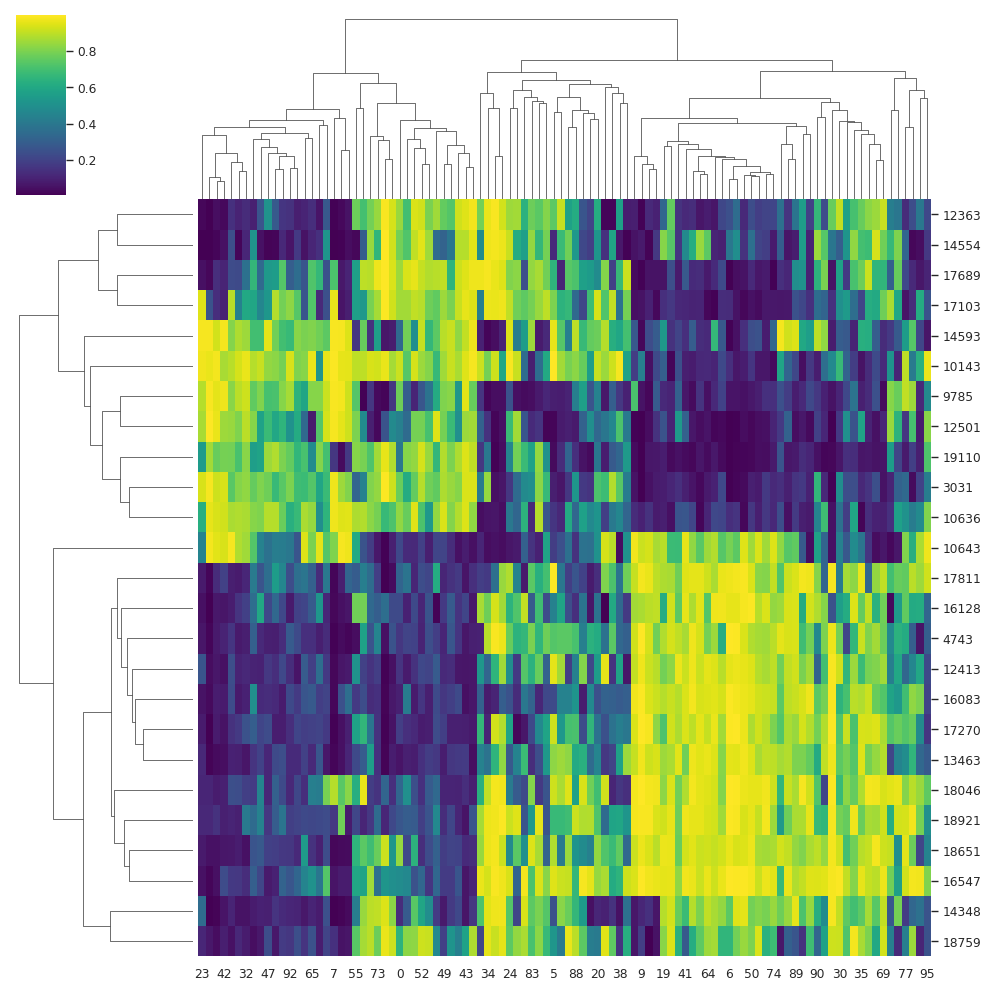

In [55]:
# make a heatmap of psis for the top 5 junctions across factors
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(8, 6))
ax = sns.clustermap(psis_df[psis_df.columns[0:K]].iloc[0:25], cmap="viridis")

### Take model with K=100 and prune the very lowly used factors. Re-calculate performance metrics (1) without re-normalizing pi vector and (2) with normalizing pi vector

In [56]:
# extract latent variables for all iterations 
latent_results = {} 
for i in range(len(all_results)):
    latent_vars = all_results[i]['latent_vars']
    pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
    conc = latent_vars["conc"] # one scaling value 
    assign_post = latent_vars["assign"]
    psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster
    a = latent_vars["a"] 
    b = latent_vars["b"] 
    print("The inferred concentration parameter is: " + str(conc))
    print("The inferred pi parameter is: " + str(pi))
    # add all latent variables to latent_results dictionary
    latent_results[i] = {"pi": pi, "conc": conc, "assign_post": assign_post, "psis": psis, "a": a, "b": b}

The inferred concentration parameter is: 14.504901
The inferred pi parameter is: [0.01413374 0.01303047 0.01285806 0.0139025  0.02245145 0.01253192
 0.06136627 0.03376384 0.01429434 0.04527318 0.01026759 0.00922047
 0.00983561 0.0293477  0.00965572 0.00934862 0.00981201 0.00911985
 0.01721708 0.00909846 0.00910249 0.009224   0.01375313 0.01244368
 0.00853797 0.01789392 0.01327393 0.00833724 0.0081729  0.02533047
 0.0074137  0.01252401 0.00780191 0.00762256 0.0129658  0.00755327
 0.01450218 0.00836459 0.00766498 0.00716042 0.00710108 0.00821382
 0.00851112 0.00995051 0.00983788 0.00989762 0.01181843 0.0075049
 0.00788117 0.00814267 0.00914147 0.00682588 0.00865568 0.00772355
 0.00756308 0.00638386 0.00654018 0.0088448  0.00962196 0.0070169
 0.00767038 0.00736191 0.00887734 0.0081377  0.00826344 0.00643155
 0.00570652 0.00748408 0.00575394 0.00850658 0.00621822 0.00757912
 0.00584274 0.00629906 0.00615496 0.0061898  0.00699869 0.00776112
 0.0058963  0.00535759 0.00609456 0.00654655 0.006

In [57]:
# iterate through all results and evaluate pi from latent variables, remove pi values that are less than 0.01

pruned_latent_results = []

for i in range(len(latent_results)):
    pi = latent_results[i]["pi"]
    
    # identify factors with pi less than 0.01
    pi_less_001 = np.where(pi < 0.01)
    
    # remove these factors from pi
    pi = np.delete(pi, pi_less_001)

    # remove these factors from psis
    psis = latent_results[i]["psis"]
    psis = np.delete(psis, pi_less_001, axis=0)

    # remove these factors from assign_post
    assign_post = latent_results[i]["assign_post"]
    assign_post = np.delete(assign_post, pi_less_001, axis=1)
    
    # also save a, b and conc 
    a = latent_results[i]["a"]
    b = latent_results[i]["b"]
    conc = latent_results[i]["conc"]

    print("The final number of factors is: " + str(len(pi)))
    # add to pruned_latent_results
    pruned_latent_results.append({"pi": pi, "conc": conc, "assign_post": assign_post, "psis": psis, "a": a, "b": b})

The final number of factors is: 22
The final number of factors is: 27
The final number of factors is: 25
The final number of factors is: 28
The final number of factors is: 27
The final number of factors is: 30
The final number of factors is: 30
The final number of factors is: 28
The final number of factors is: 28
The final number of factors is: 30


In [58]:
# from dictionary of latent variables, get the assign_post for each iteration and add to a dataframe
assign_post = []
for i in range(len(pruned_latent_results)):
    assign_post_df = pd.DataFrame(pruned_latent_results[i]["assign_post"])
    assign_post_df["new_cell_type"] = cell_types_id.new_cell_type.values
    print(assign_post_df.new_cell_type.value_counts())
    assign_post.append(pruned_latent_results[i]["assign_post"])

0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64
0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64


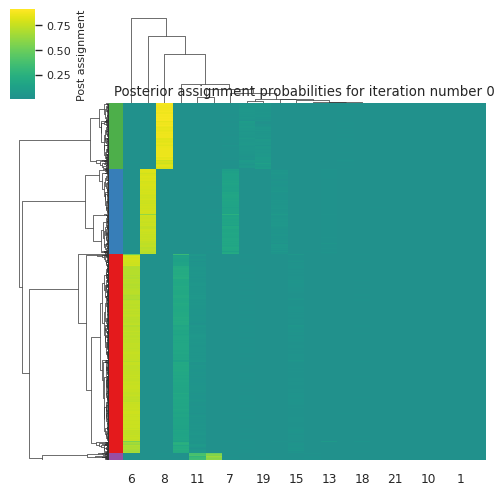

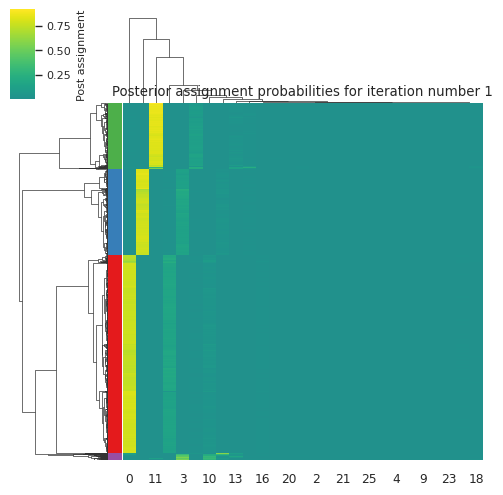

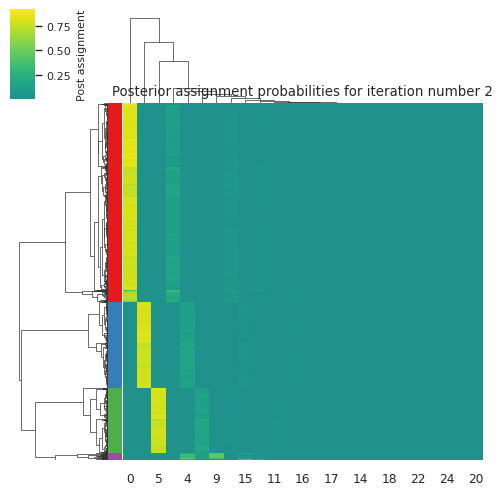

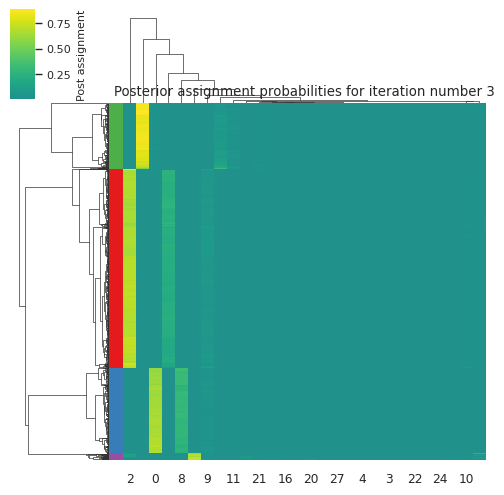

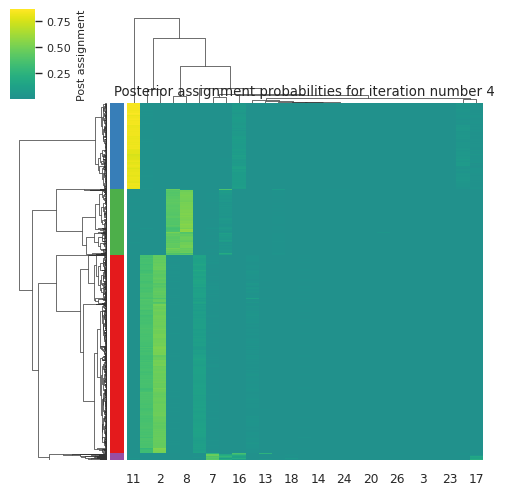

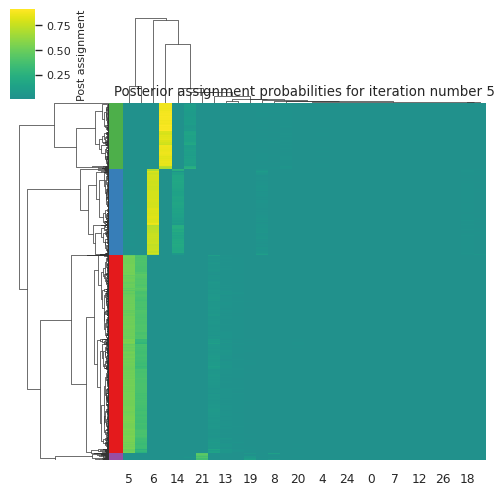

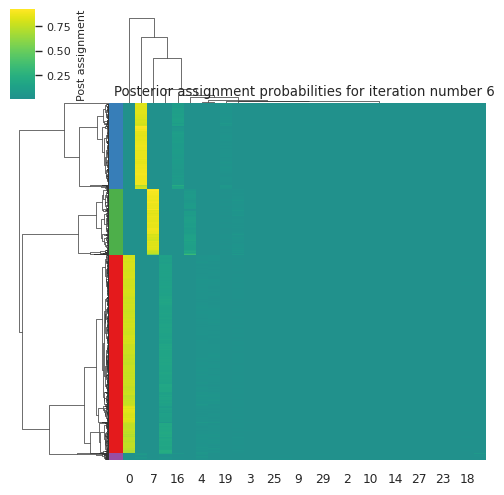

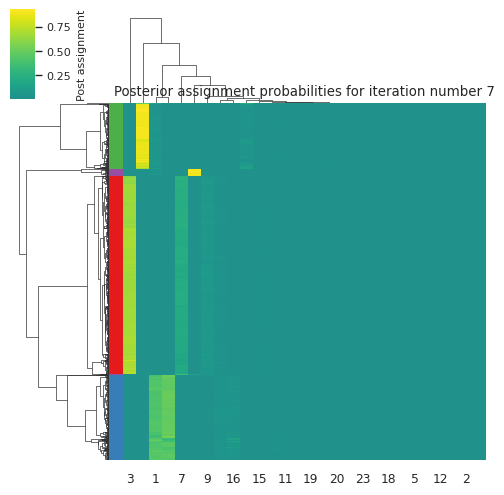

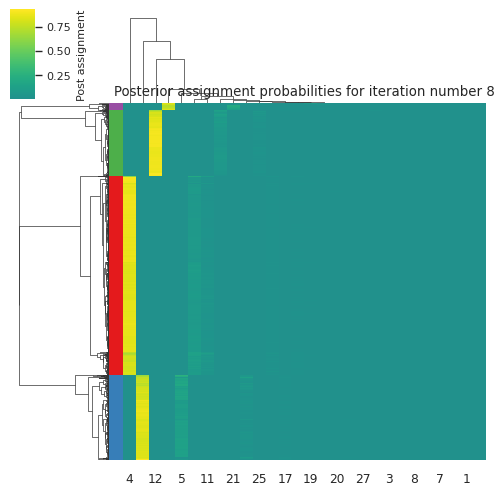

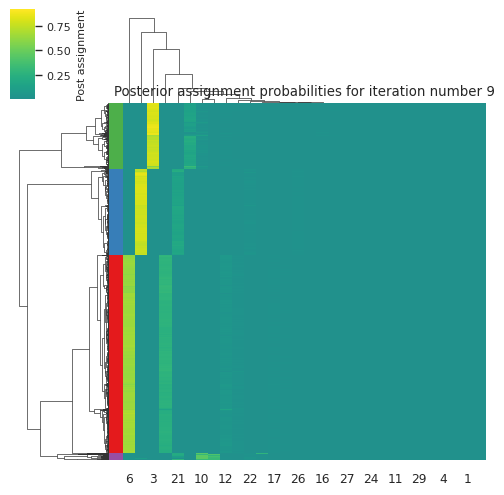

In [59]:
import seaborn as sns

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_id['new_cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_id['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_id.new_cell_type.values

# create colours for each cell type 
cell_type_colors = {new_cell_type: color for new_cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[new_cell_type] for new_cell_type in cell_types]

for i in range(len(assign_post)):
    cluster = sns.clustermap(
        data=assign_post[i],
        method='complete',
        cmap="viridis",
        annot=False,
        fmt=".2f",
        yticklabels=False,
        figsize=(5, 5),
        center=0,
        row_colors=row_colors,  # Apply row colors
        cbar_kws={'label': 'Post assignment'} 
        )
    cluster.cax.set_ylabel('Post assignment', size=8)
    # add title 
    cluster.ax_heatmap.set_title('Posterior assignment probabilities for iteration number ' + str(i))
    # Increase font size for color bar tick labels:
    cbar_ax = cluster.cax
    for label in cbar_ax.yaxis.get_ticklabels():
        label.set_size(8)

In [74]:
# evaluate pruned models on masking tasks 
# Now can run factor model on masked data
Ks = [10, 20, 100, 500]
all_Ks_results = {}
# Seeds used for masking 
seeds_used 

# define list of seeds for training factor model 
seeds = [42, 43, 44]
masked_perf_w_pruning = []

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=True, K=k, seeds=seeds,loss_plot=False, num_epochs=70, lr = 0.01, save_to_file = False)
        # prune the results based on pi to only keep factors with pi > 0.01 and evaluate the model 

        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]
            pi = res['latent_vars']["pi"]

            # get max usage across cells for each factor via assign_post
            max_usage = np.max(assign_post, axis=0)
            print("The max usage across cells for each factor is: " + str(max_usage))

            # let's prune the results based on max_usage to only keep factors with max_usage > 0.01
            max_usage_less_001 = np.where(max_usage < 0.01)
            print(psi.shape)
            psi = np.delete(psi, max_usage_less_001, axis=0)
            print(psi.shape)
            print(assign_post.shape)
            assign_post = np.delete(assign_post, max_usage_less_001, axis=1)
            print(assign_post.shape)
            
            pi = np.delete(pi, max_usage_less_001)
            
            print("The number of factors after pruning is: " + str(len(pi)))
            new_K = len(pi)

            # if new_K is empty of nan replace with 0
            if np.isnan(new_K):
                new_K = 0
            
            old_k = k 

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2, rmse = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, rmse, old_k, new_K, masking_percs[i], J, nepoch])

------------------------------------------------
Running factor model for K = 10
------------------------------------------------
The masking percentage is: 0.05
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 42
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 182652714.2711765
Epoch 20, Loss: 157950954.48836783
Epoch 40, Loss: 137520839.32183644
Epoch 60, Loss: 120347753.27303156
Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 43
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 183737457.1121579
Epoch 20, Loss: 158842636.72098753
Epoch 40, Loss: 138100066.4568613
Epoch 60, Loss: 121138303.71545959
Sample from the guide (posterior)
Extract the latent variables
Initialization 3 with seed 44
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Loss: 181327953

/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:187: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.24104142
Spearman correlation:  0.34840754661933404
L2 error:  0.09165016
RMSE:  0.30273777
The max usage across cells for each factor is: [0.20223747 0.21561155 0.24592787 0.21611455 0.15694353 0.19986512
 0.21275586 0.21997643 0.24715401 0.24456367]
(10, 19164)
(10, 19164)
(2405, 10)
(2405, 10)
The number of factors after pruning is: 10
L1 error:  0.2419434
Spearman correlation:  0.3496617564567738
L2 error:  0.09208562
RMSE:  0.30345613
The max usage across cells for each factor is: [0.23853564 0.19801562 0.19047707 0.23871666 0.18514344 0.2255573
 0.21808803 0.21689638 0.28513154 0.22989096]
(10, 19164)
(10, 19164)
(2405, 10)
(2405, 10)
The number of factors after pruning is: 10
L1 error:  0.24022508
Spearman correlation:  0.34716266335489576
L2 error:  0.09153472
RMSE:  0.30254704
The masking percentage is: 0.1
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 42
Define the guide using AutoDiagonalNormal based on the model str

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


L1 error:  0.33343753
Spearman correlation:  nan
L2 error:  0.20176929
RMSE:  0.44918737
The max usage across cells for each factor is: [0.00688963 0.00458665 0.00804453 0.00569682 0.00420481 0.0077428
 0.00867463 0.00639292 0.00751874 0.00566854 0.00659931 0.00851654
 0.00538523 0.00604162 0.00802091 0.00625217 0.00526263 0.00711544
 0.00776452 0.00824381 0.00629637 0.00598699 0.00696215 0.00843625
 0.00553983 0.00793335 0.00765201 0.00721673 0.00904963 0.01000725
 0.00799901 0.00780283 0.0062002  0.00762218 0.00827087 0.00677503
 0.00734896 0.00784421 0.00778591 0.00614706 0.00717923 0.00695506
 0.00773874 0.00741213 0.00430927 0.00653976 0.00846913 0.00592391
 0.00678423 0.00775137 0.00780356 0.00747933 0.00784981 0.00426148
 0.00805017 0.00700188 0.00670354 0.00733822 0.00859801 0.00799736
 0.00634567 0.00782663 0.00515108 0.00635869 0.00596151 0.00674164
 0.0076345  0.0076351  0.00687437 0.00773498 0.00675107 0.00744407
 0.00665693 0.00738396 0.00746253 0.00581872 0.00684247 0.007

In [75]:
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "old_k", "K",  "perc_masked" , "J", "num_epochs"])
masked_perf_df.tail()

,seed,l1,r,l2,rmse,old_k,K,perc_masked,J,num_epochs
226,43,0.333084,NaN,0.201611,0.449012,500,0.0,0.1001,19164,70.0
227,44,0.333084,NaN,0.201611,0.449012,500,0.0,0.1001,19164,70.0
228,42,0.333129,NaN,0.201625,0.449027,500,0.0,0.2000,19164,70.0
229,43,0.333129,NaN,0.201625,0.449027,500,0.0,0.2000,19164,70.0
230,44,0.332536,0.165411,0.200952,0.448276,500,1.0,0.2000,19164,70.0


In [78]:
masked_perf_df[masked_perf_df["old_k"] == 100]

,seed,l1,r,l2,rmse,old_k,K,perc_masked,J,num_epochs
24,42,0.237618,0.368364,0.089021,0.298364,100,0.0500,19164.0000,70,NaN
25,43,0.238595,0.368475,0.089412,0.299018,100,0.0500,19164.0000,70,NaN
26,44,0.236919,0.367497,0.088700,0.297825,100,0.0500,19164.0000,70,NaN
27,42,0.237761,0.367672,0.089102,0.298500,100,0.1000,19164.0000,70,NaN
28,43,0.238715,0.367929,0.089480,0.299131,100,0.1000,19164.0000,70,NaN
29,44,0.237044,0.366961,0.088768,0.297939,100,0.1000,19164.0000,70,NaN
30,42,0.237767,0.367696,0.089105,0.298504,100,0.1001,19164.0000,70,NaN
31,43,0.238730,0.367907,0.089487,0.299144,100,0.1001,19164.0000,70,NaN
32,44,0.237045,0.366958,0.088776,0.297953,100,0.1001,19164.0000,70,NaN
33,42,0.238491,0.364127,0.089559,0.299264,100,0.2000,19164.0000,70,NaN


In [73]:
masked_perf_df.rmse.unique().min()

0.2978251

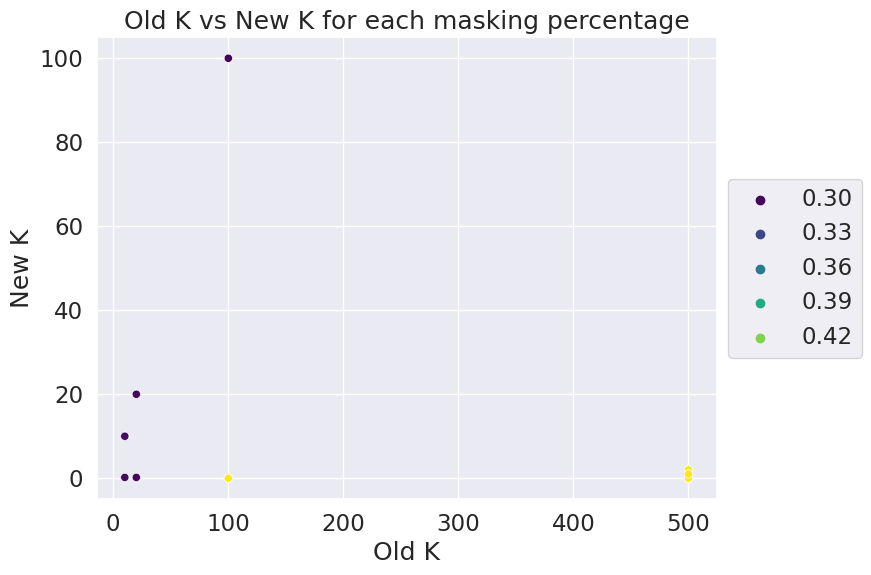

In [77]:
# make scatterplot of old_k vs new_K for each masking percentage and colour by rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(x="old_k", y="K", data=masked_perf_df, hue="rmse", palette="viridis")
# make rmse color continous 
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
ax.set_xlabel("Old K")
ax.set_ylabel("New K")
ax.set_title("Old K vs New K for each masking percentage")
plt.show()

In [ ]:
# fit with 100 factors and then prune and get 20 factors, expect to get better metrics than just K=20 factors 
# can also re-normalize the pi vector after prunning 